# Notebook 04: Supervised Modeling & Model Selection

**Project 4 -- End-to-End Machine Learning: LendingClub Loan Default Prediction**

This notebook trains, tunes, and compares four supervised models for predicting loan default:

0. **Logistic Regression** (baseline) -- ElasticNet regularization, interpretable coefficients
1. **Random Forest** -- tree-based, robust feature importance
2. **PyTorch Neural Network** -- deep MLP with BatchNorm, Dropout, early stopping
3. **XGBoost** -- gradient boosting, consistently top performer on tabular data

**Leak-Free Pipeline:**
- Load `engineered.parquet` (deterministic transforms only from NB03)
- Temporal train/val/test split (pre-2015-07 / 2015 H2 / 2016+)
- **Train-aware preprocessing**: addr_state target encoding, NZV filter, high-correlation filter, StandardScaler — all fit on training data only
- **TimeSeriesSplit** for hyperparameter tuning (respects temporal order)
- **Isotonic calibration** for all models (not just XGBoost)
- Val set split: first half for calibration, second half for threshold tuning
- F2-optimized + cost-based threshold optimization
- Application-time vs investor model comparison
- Right-censoring sensitivity analysis
- SHAP model interpretability

**Input:** `data/engineered.parquet`, `data/temporal_split_index.parquet`

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import time
import pickle
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             fbeta_score, roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay,
                             matthews_corrcoef, brier_score_loss, make_scorer)
from xgboost import XGBClassifier

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 60)

C_GREEN  = '#2ecc71'
C_RED    = '#e74c3c'
C_BLUE   = '#3498db'
C_ORANGE = '#f39c12'
C_PURPLE = '#9b59b6'
C_TEAL   = '#1abc9c'
C_PINK   = '#e91e63'

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cpu')
N_JOBS = -1
torch.set_num_threads(1)

print(f"Libraries loaded. Device: {device}")
print(f"PyTorch threads: {torch.get_num_threads()}")
print(f"sklearn n_jobs: {N_JOBS} (all cores)")

Libraries loaded. Device: cpu
PyTorch threads: 1
sklearn n_jobs: -1 (all cores)


## 1. Load Data & Temporal Train/Val/Test Split

We load `engineered.parquet` which contains **unscaled** features with `addr_state` as a string column. Data-dependent transforms (target encoding, NZV filter, correlation filter, StandardScaler) are applied in Section 2, fit on training data only.

**Temporal split:**
- **Train** (pre-2015-07): ~640K rows
- **Validation** (2015 H2): ~190K rows — first half calibration, second half threshold tuning
- **Test** (2016+): ~518K rows

In [2]:
df = pd.read_parquet('data/engineered.parquet')
temporal = pd.read_parquet('data/temporal_split_index.parquet')

print(f"Engineered features shape: {df.shape}")
print(f"Temporal index shape: {temporal.shape}")
print(f"Target distribution:\n{df['loan_status'].value_counts()}")
print(f"\nOverall default rate: {df['loan_status'].mean():.2%}")
print(f"addr_state dtype: {df['addr_state'].dtype} (to be target-encoded below)")

Engineered features shape: (1345310, 90)
Temporal index shape: (1345310, 1)
Target distribution:
loan_status
0    1076751
1     268559
Name: count, dtype: int64

Overall default rate: 19.96%
addr_state dtype: str (to be target-encoded below)


In [3]:
# Temporal split
train_mask = temporal['issue_d'] < '2015-07-01'
val_mask   = (temporal['issue_d'] >= '2015-07-01') & (temporal['issue_d'] < '2016-01-01')
test_mask  = temporal['issue_d'] >= '2016-01-01'

# Keep as DataFrames for preprocessing
df_train = df.loc[train_mask].copy()
df_val   = df.loc[val_mask].copy()
df_test  = df.loc[test_mask].copy()

# Save temporal arrays for CV sorting and right-censoring
train_dates = temporal.loc[train_mask, 'issue_d'].values
val_dates   = temporal.loc[val_mask, 'issue_d'].values
test_dates  = temporal.loc[test_mask, 'issue_d'].values

# Save raw term for right-censoring analysis (before scaling)
term_test = df_test['term'].values.copy()

print(f"Train: {df_train.shape}  (default rate: {df_train['loan_status'].mean():.2%})")
print(f"Val:   {df_val.shape}  (default rate: {df_val['loan_status'].mean():.2%})")
print(f"Test:  {df_test.shape}  (default rate: {df_test['loan_status'].mean():.2%})")
print(f"\nDate ranges:")
print(f"  Train: {train_dates.min()} to {train_dates.max()}")
print(f"  Val:   {val_dates.min()} to {val_dates.max()}")
print(f"  Test:  {test_dates.min()} to {test_dates.max()}")

del df, temporal

Train: (613804, 90)  (default rate: 17.86%)
Val:   (212800, 90)  (default rate: 20.06%)
Test:  (518706, 90)  (default rate: 22.41%)

Date ranges:
  Train: 2007-06-01T00:00:00.000000 to 2015-06-01T00:00:00.000000
  Val:   2015-07-01T00:00:00.000000 to 2015-12-01T00:00:00.000000
  Test:  2016-01-01T00:00:00.000000 to 2018-12-01T00:00:00.000000


## 2. Train-Aware Preprocessing (Fit on Training Data Only)

All data-dependent transforms are fit on **training data only** to prevent information leakage:

1. **addr_state target encoding**: Smoothed mean of `loan_status` by state (λ=100)
2. **Near-zero-variance filter**: Drop columns where >99.5% of training rows have a single value
3. **High-correlation filter**: For |r| > 0.90 pairs on train, drop the one with lower target correlation
4. **StandardScaler**: Fit on training features, transform all splits

These were previously applied to the full dataset in NB03 (leakage). Now correctly scoped.

In [4]:
# --- 2.1 addr_state Target Encoding (fit on train labels only) ---
SMOOTHING = 100
global_mean = df_train['loan_status'].mean()
state_stats = df_train.groupby('addr_state')['loan_status'].agg(['mean', 'count'])
state_stats['smoothed'] = (
    state_stats['count'] * state_stats['mean'] + SMOOTHING * global_mean
) / (state_stats['count'] + SMOOTHING)
state_encoding = state_stats['smoothed'].to_dict()

for split_df in [df_train, df_val, df_test]:
    split_df['addr_state'] = split_df['addr_state'].map(state_encoding).fillna(global_mean)

print("addr_state target encoding:")
print(f"  States encoded: {len(state_encoding)}")
print(f"  Global mean: {global_mean:.4f}")
print(f"  Example: CA={state_encoding.get('CA', 'N/A'):.4f}, NY={state_encoding.get('NY', 'N/A'):.4f}")

addr_state target encoding:
  States encoded: 50
  Global mean: 0.1786
  Example: CA=0.1723, NY=0.1941


In [5]:
# --- 2.2 Near-Zero-Variance Filter (fit on train) ---
feature_cols = [c for c in df_train.columns if c != 'loan_status']
nzv_threshold = 0.995

mode_fracs = df_train[feature_cols].apply(lambda c: c.value_counts(normalize=True).iloc[0])
nzv_cols = mode_fracs[mode_fracs > nzv_threshold].index.tolist()

print(f"NZV columns (>{nzv_threshold*100:.1f}% single value): {len(nzv_cols)}")
for col in nzv_cols:
    print(f"  {col}: {mode_fracs[col]:.4f}")

for split_df in [df_train, df_val, df_test]:
    split_df.drop(columns=nzv_cols, inplace=True)

# --- 2.3 High-Correlation Filter (fit on train) ---
feature_cols = [c for c in df_train.columns if c != 'loan_status']
corr_matrix = df_train[feature_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

target_corr = df_train[feature_cols].corrwith(df_train['loan_status']).abs()
drop_corr = set()
for col in upper.columns:
    for row in upper.index:
        val = upper.loc[row, col]
        if pd.notna(val) and val > 0.90:
            drop = row if target_corr.get(col, 0) >= target_corr.get(row, 0) else col
            drop_corr.add(drop)

print(f"\nHigh-correlation columns dropped (|r|>0.90): {len(drop_corr)}")
if drop_corr:
    for col in sorted(drop_corr):
        print(f"  {col}")

for split_df in [df_train, df_val, df_test]:
    split_df.drop(columns=list(drop_corr), inplace=True)

print(f"\nShape after NZV + correlation filter: {df_train.shape}")

NZV columns (>99.5% single value): 7
  acc_now_delinq: 0.9957
  delinq_amnt: 0.9971
  num_tl_120dpd_2m: 0.9993
  num_tl_30dpd: 0.9973
  home_ownership_OTHER: 0.9997
  purpose_house: 0.9954
  application_type_Joint App: 1.0000

High-correlation columns dropped (|r|>0.90): 9
  installment
  installment_to_income
  int_rate
  mths_since_last_delinq_missing
  mths_since_recent_bc_dlq
  mths_since_recent_revol_delinq
  num_actv_rev_tl
  num_sats
  tot_cur_bal

Shape after NZV + correlation filter: (613804, 74)


In [6]:
# --- 2.4 StandardScaler (fit on train) + Feature Sets + Numpy ---
feature_names = [c for c in df_train.columns if c != 'loan_status']
app_features = [c for c in feature_names if c != 'sub_grade']

scaler = StandardScaler()
X_train = scaler.fit_transform(df_train[feature_names].values)
X_val   = scaler.transform(df_val[feature_names].values)
X_test  = scaler.transform(df_test[feature_names].values)

y_train = df_train['loan_status'].values
y_val   = df_val['loan_status'].values
y_test  = df_test['loan_status'].values

# Application-time features (no sub_grade)
app_idx = [feature_names.index(f) for f in app_features]
X_train_app = X_train[:, app_idx]
X_val_app   = X_val[:, app_idx]
X_test_app  = X_test[:, app_idx]

print(f"Final preprocessed shapes:")
print(f"  X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape}    y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}   y_test:  {y_test.shape}")
print(f"\nFeature sets:")
print(f"  Investor (with sub_grade): {len(feature_names)}")
print(f"  Application-time (no sub_grade): {len(app_features)}")

# Save artifacts
artifacts = {
    'scaler': scaler, 'state_encoding': state_encoding,
    'nzv_cols': nzv_cols, 'drop_corr': list(drop_corr),
    'feature_names': feature_names, 'app_features': app_features,
}
with open('data/preprocessing_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)
print("Saved preprocessing artifacts to data/preprocessing_artifacts.pkl")

del df_train, df_val, df_test

Final preprocessed shapes:
  X_train: (613804, 73)  y_train: (613804,)
  X_val:   (212800, 73)    y_val:   (212800,)
  X_test:  (518706, 73)   y_test:  (518706,)

Feature sets:
  Investor (with sub_grade): 73
  Application-time (no sub_grade): 72
Saved preprocessing artifacts to data/preprocessing_artifacts.pkl


## 2. Handling Class Imbalance: Class Weights 

Instead of SMOTE (which creates synthetic samples and destroys probability calibration), we use **class weights** built into each model's loss function:

- **Random Forest**: `class_weight='balanced'` -- automatically weights classes inversely proportional to frequency
- **XGBoost**: `scale_pos_weight = neg_count / pos_count` -- scales the gradient for positive (default) class
- **PyTorch MLP**: `pos_weight` in BCEWithLogitsLoss -- directly upweights the positive class in the loss function

This approach:
1. Trains on real data only (no synthetic artifacts)
2. Preserves probability calibration
3. Is computationally cheaper (no 500K+ synthetic samples)
4. Achieves comparable or better performance per academic benchmarks

In [7]:
# Class distribution and weight computation
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print("Training set class distribution:")
print(f"  Class 0 (Fully Paid):  {neg_count:,}")
print(f"  Class 1 (Charged Off): {pos_count:,}")
print(f"  Default rate: {y_train.mean():.2%}")
print(f"\nClass weight ratio (neg/pos): {scale_pos_weight:.2f}")
print(f"  → RF will use class_weight='balanced'")
print(f"  → XGBoost will use scale_pos_weight={scale_pos_weight:.2f}")
print(f"  → MLP will use pos_weight in BCEWithLogitsLoss")

Training set class distribution:
  Class 0 (Fully Paid):  504,185
  Class 1 (Charged Off): 109,619
  Default rate: 17.86%

Class weight ratio (neg/pos): 4.60
  → RF will use class_weight='balanced'
  → XGBoost will use scale_pos_weight=4.60
  → MLP will use pos_weight in BCEWithLogitsLoss


In [8]:
# Tuning subset sorted temporally for TimeSeriesSplit
TUNE_SIZE = 80_000
np.random.seed(42)
tune_idx = np.random.choice(len(X_train), size=min(TUNE_SIZE, len(X_train)), replace=False)

# Sort by issue date for temporal CV
tune_dates = train_dates[tune_idx]
tune_sort = np.argsort(tune_dates)
tune_idx_sorted = tune_idx[tune_sort]

X_tune = X_train[tune_idx_sorted]
y_tune = y_train[tune_idx_sorted]

cv_temporal = TimeSeriesSplit(n_splits=3)

print(f"Tuning subset: {X_tune.shape} (sorted by issue date)")
print(f"  Class 0: {(y_tune == 0).sum():,}  Class 1: {(y_tune == 1).sum():,}")
print(f"  Default rate: {y_tune.mean():.2%}")
print(f"  CV: TimeSeriesSplit(n_splits=3)")

Tuning subset: (80000, 73) (sorted by issue date)
  Class 0: 65,642  Class 1: 14,358
  Default rate: 17.95%
  CV: TimeSeriesSplit(n_splits=3)


## 3. Model 0: Logistic Regression (Baseline)

ElasticNet logistic regression with `class_weight='balanced'` provides an interpretable baseline.

### 3.0.1 Hyperparameter Tuning + Retrain

In [9]:
lr_param_dist = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0],
    'l1_ratio': [0.0, 0.25, 0.5, 0.75, 1.0],
}

lr_search = RandomizedSearchCV(
    LogisticRegression(penalty='elasticnet', solver='saga', class_weight='balanced',
                       max_iter=1000, random_state=42),
    lr_param_dist,
    n_iter=10, scoring='average_precision', cv=cv_temporal,
    random_state=42, n_jobs=N_JOBS, verbose=1
)

t0 = time.time()
lr_search.fit(X_tune, y_tune)
t_lr_tune = time.time() - t0

print(f"\nBest CV PR-AUC: {lr_search.best_score_:.4f}")
print(f"Best params: {lr_search.best_params_}")
print(f"Tuning time: {t_lr_tune:.1f}s")

# Retrain on full training set
lr_best = LogisticRegression(
    **lr_search.best_params_, penalty='elasticnet', solver='saga',
    class_weight='balanced', max_iter=1000, random_state=42
)
t0 = time.time()
lr_best.fit(X_train, y_train)
t_lr_train = time.time() - t0

lr_prob = lr_best.predict_proba(X_test)[:, 1]
lr_val_prob = lr_best.predict_proba(X_val)[:, 1]
lr_pred = lr_best.predict(X_test)

print(f"LR training time (full data): {t_lr_train:.1f}s")
print(f"Non-zero coefficients: {(lr_best.coef_[0] != 0).sum()} / {len(feature_names)}")

print(f"\n{'='*60}")
print("Logistic Regression -- Test Set (default theta=0.5)")
print(f"{'='*60}")
print(classification_report(y_test, lr_pred, target_names=['Fully Paid', 'Charged Off']))
print(f"AUC-ROC:  {roc_auc_score(y_test, lr_prob):.4f}")
print(f"PR-AUC:   {average_precision_score(y_test, lr_prob):.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best CV PR-AUC: 0.3679
Best params: {'l1_ratio': 1.0, 'C': 0.01}
Tuning time: 26.8s
LR training time (full data): 46.6s
Non-zero coefficients: 70 / 73

Logistic Regression -- Test Set (default theta=0.5)
              precision    recall  f1-score   support

  Fully Paid       0.86      0.68      0.76    402449
 Charged Off       0.36      0.62      0.45    116257

    accuracy                           0.67    518706
   macro avg       0.61      0.65      0.61    518706
weighted avg       0.75      0.67      0.69    518706

AUC-ROC:  0.7098
PR-AUC:   0.3937


## 3. Model 1: Random Forest

Random Forest handles feature interactions naturally, is robust to outliers, and provides built-in feature importance rankings. We use `class_weight='balanced'` to handle imbalance directly in the loss function.

### 3.1 Hyperparameter Tuning

`RandomizedSearchCV` with 10 iterations and 3-fold stratified CV on the 50K tuning subset. Scoring uses **PR-AUC** (`average_precision`), which is more informative than ROC-AUC for imbalanced data.

In [10]:
rf_param_dist = {
    'n_estimators': [200, 300, 500, 700],
    'max_depth': [10, 15, 20, 25, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', 0.3, 0.5],
    'criterion': ['gini', 'entropy'],
    'max_samples': [0.7, 0.8, 0.9, None],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    rf_param_dist,
    n_iter=30, scoring='average_precision', cv=cv_temporal,
    random_state=42, n_jobs=-1, verbose=1
)

t0 = time.time()
rf_search.fit(X_tune, y_tune)
t_rf_tune = time.time() - t0

print(f"\nBest CV PR-AUC: {rf_search.best_score_:.4f}")
print(f"Best params: {rf_search.best_params_}")
print(f"Tuning time: {t_rf_tune:.1f}s")

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best CV PR-AUC: 0.3666
Best params: {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 8, 'max_samples': 0.7, 'max_features': 'sqrt', 'max_depth': None, 'criterion': 'entropy'}
Tuning time: 791.3s


### 3.2 Retrain on Full Training Set

Retrain with the best hyperparameters and `class_weight='balanced'` on the full training set for maximum performance.

In [11]:
rf_best = RandomForestClassifier(**rf_search.best_params_, class_weight='balanced',
                                 random_state=42, n_jobs=-1)

t0 = time.time()
rf_best.fit(X_train, y_train)
t_rf_train = time.time() - t0
print(f"RF training time (full data): {t_rf_train:.1f}s")

# Predictions at default threshold (for baseline comparison)
rf_prob = rf_best.predict_proba(X_test)[:, 1]
rf_pred = rf_best.predict(X_test)
rf_val_prob = rf_best.predict_proba(X_val)[:, 1]

print(f"\n{'='*60}")
print("Random Forest — Test Set (default θ=0.5)")
print(f"{'='*60}")
print(classification_report(y_test, rf_pred, target_names=['Fully Paid', 'Charged Off']))
print(f"AUC-ROC:  {roc_auc_score(y_test, rf_prob):.4f}")
print(f"PR-AUC:   {average_precision_score(y_test, rf_prob):.4f}")

RF training time (full data): 151.9s

Random Forest — Test Set (default θ=0.5)
              precision    recall  f1-score   support

  Fully Paid       0.81      0.93      0.86    402449
 Charged Off       0.48      0.23      0.31    116257

    accuracy                           0.77    518706
   macro avg       0.65      0.58      0.59    518706
weighted avg       0.73      0.77      0.74    518706

AUC-ROC:  0.7140
PR-AUC:   0.4085


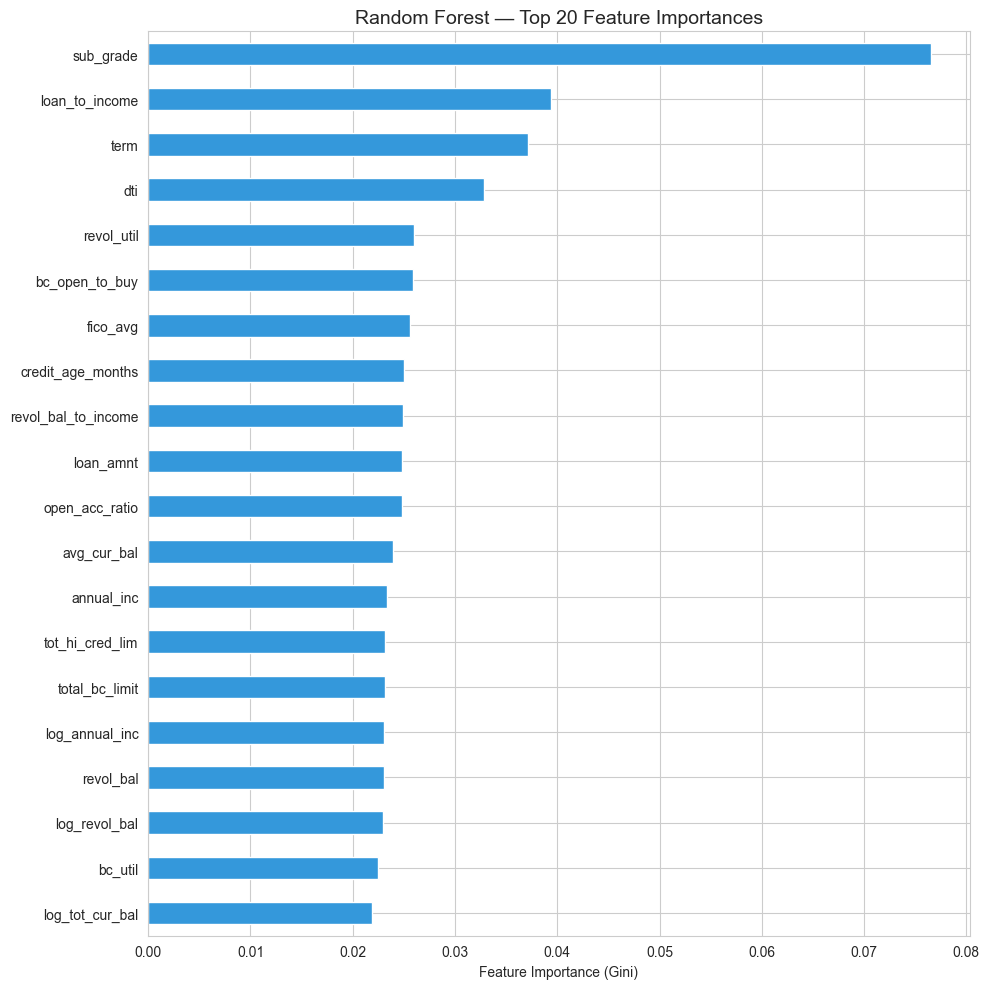


Top 20 features:
  1. sub_grade: 0.0765
  2. loan_to_income: 0.0393
  3. term: 0.0371
  4. dti: 0.0329
  5. revol_util: 0.0260
  6. bc_open_to_buy: 0.0259
  7. fico_avg: 0.0256
  8. credit_age_months: 0.0250
  9. revol_bal_to_income: 0.0249
  10. loan_amnt: 0.0248
  11. open_acc_ratio: 0.0248
  12. avg_cur_bal: 0.0239
  13. annual_inc: 0.0234
  14. tot_hi_cred_lim: 0.0232
  15. total_bc_limit: 0.0232
  16. log_annual_inc: 0.0230
  17. revol_bal: 0.0230
  18. log_revol_bal: 0.0230
  19. bc_util: 0.0225
  20. log_tot_cur_bal: 0.0218


In [12]:
# Feature importance — top 20
importances = rf_best.feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
feat_imp.tail(20).plot(kind='barh', ax=ax, color=C_BLUE, edgecolor='white')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Random Forest — Top 20 Feature Importances', fontsize=14)
plt.tight_layout()
plt.show()

print("\nTop 20 features:")
for i, (name, imp) in enumerate(feat_imp.tail(20).iloc[::-1].items(), 1):
    print(f"  {i}. {name}: {imp:.4f}")

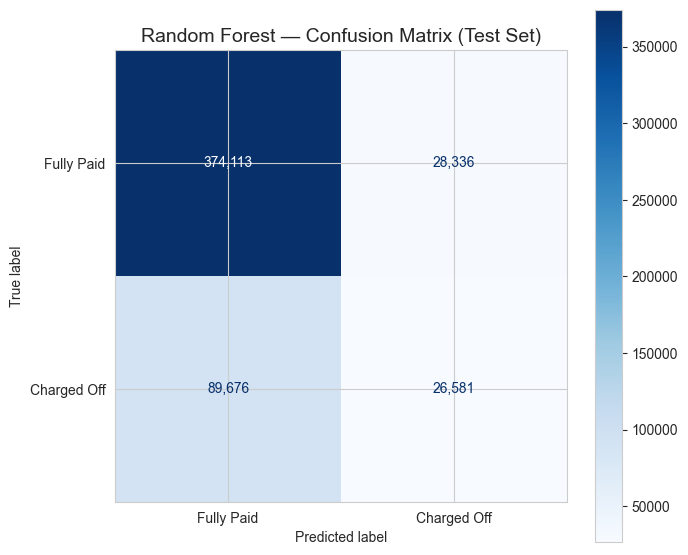

In [13]:
# Confusion matrix — Random Forest
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred,
    display_labels=['Fully Paid', 'Charged Off'],
    cmap='Blues', ax=ax, values_format=','
)
ax.set_title('Random Forest — Confusion Matrix (Test Set)', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Model 2: PyTorch Neural Network

A custom Multi-Layer Perceptron built in PyTorch with **BatchNorm + Dropout + early stopping**. Unlike sklearn's MLPClassifier, this implementation provides:
- **Batch normalization** for faster, more stable training
- **`pos_weight` in BCEWithLogitsLoss** for native class imbalance handling (sklearn MLP lacks class weight support)
- **Learning rate scheduling** (ReduceLROnPlateau)
- **Gradient clipping** to prevent exploding gradients

Architecture: `[Linear -> BatchNorm -> ReLU -> Dropout] x N -> Linear(1)`

**Early stopping uses an internal 90/10 split of training data** (not the validation set) to prevent val set contamination.

### 4.1 Model Definition & Hyperparameter Search

In [14]:
# -- PyTorch MLP -------------------------------------------------------

class LoanDefaultMLP(nn.Module):
    '''MLP for binary loan default classification.
    Architecture: [Linear -> BatchNorm1d -> ReLU -> Dropout] x N -> Linear(1)
    '''
    def __init__(self, input_dim, hidden_dims, dropout_rate=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout_rate)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


def _make_loader(X, y, shuffle=True, batch_size=1024):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32),
                       torch.tensor(y, dtype=torch.float32))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=0)


def _train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(yb)
    return total_loss / len(loader.dataset)


def _evaluate_nn(model, loader, criterion):
    model.eval()
    total_loss, all_logits, all_labels = 0.0, [], []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = model(Xb)
            total_loss += criterion(logits, yb).item() * len(yb)
            all_logits.append(logits.cpu())
            all_labels.append(yb.cpu())
    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()
    probs  = torch.sigmoid(torch.tensor(logits)).numpy()
    return total_loss / len(loader.dataset), roc_auc_score(labels, probs), probs, labels


def _train_mlp(cfg, X_tr, y_tr, X_vl, y_vl, pw, max_epochs=50, patience=7, verbose=True):
    tr_loader = _make_loader(X_tr, y_tr, shuffle=True,  batch_size=cfg['batch_size'])
    vl_loader = _make_loader(X_vl, y_vl, shuffle=False, batch_size=cfg['batch_size'])

    model     = LoanDefaultMLP(X_tr.shape[1], cfg['hidden_dims'], cfg['dropout_rate']).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pw], dtype=torch.float32).to(device))
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

    best_score, best_state, counter = None, None, 0
    history = dict(train_loss=[], val_loss=[], val_roc=[])

    for epoch in range(1, max_epochs + 1):
        tr_loss = _train_epoch(model, tr_loader, criterion, optimizer)
        vl_loss, vl_roc, _, _ = _evaluate_nn(model, vl_loader, criterion)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['val_roc'].append(vl_roc)
        scheduler.step(vl_roc)

        improved = best_score is None or vl_roc > best_score + 1e-4
        if improved:
            best_score = vl_roc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            counter = 0
        else:
            counter += 1

        if verbose and (epoch % 5 == 0 or epoch == 1):
            print(f"  Ep {epoch:3d}: train_loss={tr_loss:.4f}  val_loss={vl_loss:.4f}  ROC-AUC={vl_roc:.4f}")

        if counter >= patience:
            if verbose:
                print(f"  Early stop @ epoch {epoch}  (best ROC-AUC={best_score:.4f})")
            break

    if best_state:
        model.load_state_dict(best_state)
    return model, history, best_score




from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.isotonic import IsotonicRegression

class MLPWrapper(ClassifierMixin, BaseEstimator):
    """Sklearn-compatible wrapper for PyTorch MLP."""
    def __init__(self, model=None, device=None):
        self.model = model
        self.device = device
        self.classes_ = np.array([0, 1])
    def fit(self, X, y=None):
        return self
    def predict_proba(self, X):
        self.model.eval()
        with torch.no_grad():
            logits = self.model(torch.tensor(X, dtype=torch.float32).to(self.device))
            probs = torch.sigmoid(logits).cpu().numpy()
        return np.column_stack([1 - probs, probs])
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)
    def __sklearn_is_fitted__(self):
        return True

class CalibratedMLPWrapper:
    """MLPWrapper + manual isotonic calibration (avoids FrozenEstimator classifier tag issues)."""
    def __init__(self, mlp_wrapper, X_cal, y_cal):
        raw_probs = mlp_wrapper.predict_proba(X_cal)[:, 1]
        self.mlp_wrapper = mlp_wrapper
        self.iso = IsotonicRegression(out_of_bounds='clip', y_min=0, y_max=1)
        self.iso.fit(raw_probs, y_cal)
        self.classes_ = np.array([0, 1])
    def predict_proba(self, X):
        raw = self.mlp_wrapper.predict_proba(X)[:, 1]
        cal = self.iso.predict(raw)
        return np.column_stack([1 - cal, cal])
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


# -- Hyperparameter search ---------------------------------------------

NN_CONFIGS = [
    {'name': 'small_low_drop',   'hidden_dims': [128, 64],       'dropout_rate': 0.2, 'lr': 1e-3,  'batch_size': 1024},
    {'name': 'medium_med_drop',  'hidden_dims': [256, 128, 64],  'dropout_rate': 0.3, 'lr': 1e-3,  'batch_size': 1024},
    {'name': 'medium_low_lr',    'hidden_dims': [256, 128, 64],  'dropout_rate': 0.3, 'lr': 3e-4,  'batch_size': 1024},
    {'name': 'wide_shallow',     'hidden_dims': [512, 256],      'dropout_rate': 0.2, 'lr': 1e-3,  'batch_size': 1024},
    {'name': 'large_high_drop',  'hidden_dims': [512, 256, 128], 'dropout_rate': 0.4, 'lr': 1e-3,  'batch_size': 1024},
    {'name': 'large_low_lr',     'hidden_dims': [512, 256, 128], 'dropout_rate': 0.3, 'lr': 3e-4,  'batch_size': 1024},
    {'name': 'deep_narrow',      'hidden_dims': [256, 128, 64, 32], 'dropout_rate': 0.3, 'lr': 3e-4, 'batch_size': 512},
]

pw_nn = neg_count / pos_count

# Internal 90/10 split for NN early stopping (preserves val for calibration)
X_nn_tr, X_nn_es, y_nn_tr, y_nn_es = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)
print(f"NN internal split: train={X_nn_tr.shape[0]:,}, early_stop={X_nn_es.shape[0]:,}")

   # pos_weight for BCEWithLogitsLoss
nn_search_results = []

print("=" * 72)
print("NEURAL NETWORK HYPERPARAMETER SEARCH  (metric=ROC-AUC, max_epochs=30, patience=5)")
print("=" * 72)

for cfg in NN_CONFIGS:
    print(f"\n  {cfg['name']}  hidden={cfg['hidden_dims']}  dropout={cfg['dropout_rate']}  lr={cfg['lr']}")
    _, _, best_auc = _train_mlp(cfg, X_nn_tr, y_nn_tr, X_nn_es, y_nn_es, pw_nn,
                                max_epochs=30, patience=5, verbose=True)
    nn_search_results.append({'name': cfg['name'], 'best_val_roc_auc': best_auc, **cfg})
    print(f"  -> Best Val ROC-AUC: {best_auc:.4f}")

nn_search_df = pd.DataFrame(nn_search_results).sort_values('best_val_roc_auc', ascending=False)
best_nn_config = next(c for c in NN_CONFIGS if c['name'] == nn_search_df.iloc[0]['name'])

print(f"\n{'='*72}")
print("SEARCH SUMMARY (sorted by Val ROC-AUC)")
print(f"{'='*72}")
print(nn_search_df[['name', 'hidden_dims', 'dropout_rate', 'lr', 'best_val_roc_auc']].to_string(index=False))
print(f"\nBest config: {best_nn_config['name']}")

NN internal split: train=552,423, early_stop=61,381
NEURAL NETWORK HYPERPARAMETER SEARCH  (metric=ROC-AUC, max_epochs=30, patience=5)

  small_low_drop  hidden=[128, 64]  dropout=0.2  lr=0.001
  Ep   1: train_loss=1.0245  val_loss=1.0051  ROC-AUC=0.7248
  Ep   5: train_loss=1.0072  val_loss=1.0018  ROC-AUC=0.7271
  Ep  10: train_loss=1.0035  val_loss=0.9997  ROC-AUC=0.7284
  Ep  15: train_loss=0.9989  val_loss=0.9986  ROC-AUC=0.7287
  Early stop @ epoch 17  (best ROC-AUC=0.7294)
  -> Best Val ROC-AUC: 0.7294

  medium_med_drop  hidden=[256, 128, 64]  dropout=0.3  lr=0.001
  Ep   1: train_loss=1.0273  val_loss=1.0046  ROC-AUC=0.7247
  Ep   5: train_loss=1.0088  val_loss=1.0025  ROC-AUC=0.7272
  Ep  10: train_loss=1.0050  val_loss=1.0004  ROC-AUC=0.7281
  Ep  15: train_loss=0.9991  val_loss=0.9984  ROC-AUC=0.7289
  Early stop @ epoch 17  (best ROC-AUC=0.7292)
  -> Best Val ROC-AUC: 0.7292

  medium_low_lr  hidden=[256, 128, 64]  dropout=0.3  lr=0.0003
  Ep   1: train_loss=1.0395  val_los

### 4.2 Retrain on Full Training Set & Evaluate

In [15]:
# Retrain best config on 90% of training data, monitor on internal 10% split
print(f"Retraining: {best_nn_config['name']}")
print("=" * 60)

t0 = time.time()
mlp_model, mlp_history, _ = _train_mlp(
    best_nn_config, X_nn_tr, y_nn_tr, X_nn_es, y_nn_es, pw_nn,
    max_epochs=60, patience=10, verbose=True
)
t_mlp_train = time.time() - t0
print(f"\nNeural Network training time: {t_mlp_train:.1f}s")
print(f"Parameters: {mlp_model.count_parameters():,}")

# -- Extract predictions -----------------------------------------------
mlp_model.eval()
with torch.no_grad():
    mlp_prob = torch.sigmoid(mlp_model(
        torch.tensor(X_test, dtype=torch.float32).to(device))).cpu().numpy()
    mlp_val_prob = torch.sigmoid(mlp_model(
        torch.tensor(X_val, dtype=torch.float32).to(device))).cpu().numpy()
mlp_pred = (mlp_prob >= 0.5).astype(int)

print(f"\n{'='*60}")
print("PyTorch Neural Network -- Test Set (default theta=0.5)")
print(f"{'='*60}")
print(classification_report(y_test, mlp_pred, target_names=['Fully Paid', 'Charged Off']))
print(f"AUC-ROC:  {roc_auc_score(y_test, mlp_prob):.4f}")
print(f"PR-AUC:   {average_precision_score(y_test, mlp_prob):.4f}")

Retraining: large_high_drop
  Ep   1: train_loss=1.0262  val_loss=1.0052  ROC-AUC=0.7236
  Ep   5: train_loss=1.0092  val_loss=1.0006  ROC-AUC=0.7277
  Ep  10: train_loss=1.0028  val_loss=0.9987  ROC-AUC=0.7288
  Ep  15: train_loss=0.9995  val_loss=0.9979  ROC-AUC=0.7295
  Ep  20: train_loss=0.9958  val_loss=0.9976  ROC-AUC=0.7295
  Ep  25: train_loss=0.9912  val_loss=0.9981  ROC-AUC=0.7292
  Early stop @ epoch 25  (best ROC-AUC=0.7295)

Neural Network training time: 99.6s
Parameters: 204,033

PyTorch Neural Network -- Test Set (default theta=0.5)
              precision    recall  f1-score   support

  Fully Paid       0.87      0.66      0.75    402449
 Charged Off       0.36      0.65      0.46    116257

    accuracy                           0.66    518706
   macro avg       0.61      0.66      0.61    518706
weighted avg       0.75      0.66      0.69    518706

AUC-ROC:  0.7167
PR-AUC:   0.4060


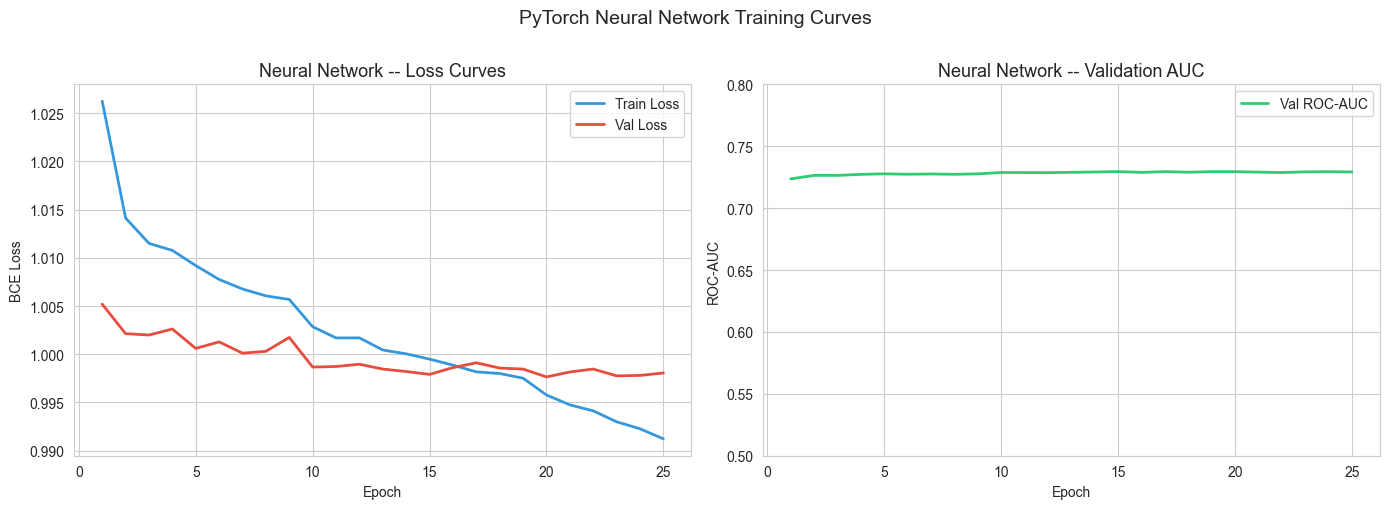

In [16]:
# Training curves
epochs_x = range(1, len(mlp_history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_x, mlp_history['train_loss'], label='Train Loss', color=C_BLUE, lw=2)
axes[0].plot(epochs_x, mlp_history['val_loss'],   label='Val Loss',   color=C_RED, lw=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].set_title('Neural Network -- Loss Curves', fontsize=13); axes[0].legend()

axes[1].plot(epochs_x, mlp_history['val_roc'], label='Val ROC-AUC', color=C_GREEN, lw=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('Neural Network -- Validation AUC', fontsize=13)
axes[1].legend(); axes[1].set_ylim([0.5, 0.8])

plt.suptitle('PyTorch Neural Network Training Curves', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

## 5. Model 3: XGBoost (with Probability Calibration)

XGBoost is consistently the top performer on tabular data. We:
1. **Tune `scale_pos_weight`** as a hyperparameter (not fixed at neg/pos ratio)
2. Add **regularization** (`gamma`, `reg_alpha`, `reg_lambda`) to the search space
3. Calibration applied in the shared calibration section below

### 5.1 Hyperparameter Tuning

In [17]:
xgb_param_dist = {
    'n_estimators': [300, 500, 700, 1000],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'learning_rate': [0.005, 0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5, 7],
    'scale_pos_weight': [1.5, 2.0, 3.0, 4.0, scale_pos_weight],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [1, 1.5, 2],
    'max_delta_step': [0, 1, 3, 5],
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(objective='binary:logistic', eval_metric='aucpr',
                  tree_method='hist', random_state=42, n_jobs=-1, verbosity=0),
    xgb_param_dist,
    n_iter=40, scoring='average_precision', cv=cv_temporal,
    random_state=42, n_jobs=1, verbose=1
)

t0 = time.time()
xgb_search.fit(X_tune, y_tune)
t_xgb_tune = time.time() - t0

print(f"\nBest CV PR-AUC: {xgb_search.best_score_:.4f}")
print(f"Best params: {xgb_search.best_params_}")
print(f"Tuning time: {t_xgb_tune:.1f}s")

Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best CV PR-AUC: 0.3690
Best params: {'subsample': 0.7, 'scale_pos_weight': 4.0, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 700, 'min_child_weight': 3, 'max_depth': 4, 'max_delta_step': 1, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.7}
Tuning time: 314.8s


### 5.2 Retrain on Full Training Set

Train with best hyperparameters on full training data. Probability calibration is deferred to the shared calibration section.

In [18]:
# Train XGBoost (calibration in shared section below)
xgb_raw = XGBClassifier(**xgb_search.best_params_,
                        objective='binary:logistic', eval_metric='aucpr',
                        random_state=42, n_jobs=-1, verbosity=0)

t0 = time.time()
xgb_raw.fit(X_train, y_train)
t_xgb_train = time.time() - t0
print(f"XGBoost training time: {t_xgb_train:.1f}s")

xgb_prob = xgb_raw.predict_proba(X_test)[:, 1]
xgb_val_prob = xgb_raw.predict_proba(X_val)[:, 1]
xgb_pred = xgb_raw.predict(X_test)

print(f"\n{'='*60}")
print("XGBoost (Raw, Pre-Calibration) -- Test Set (default theta=0.5)")
print(f"{'='*60}")
print(classification_report(y_test, xgb_pred, target_names=['Fully Paid', 'Charged Off']))
print(f"AUC-ROC:  {roc_auc_score(y_test, xgb_prob):.4f}")
print(f"PR-AUC:   {average_precision_score(y_test, xgb_prob):.4f}")
print(f"Brier (raw): {brier_score_loss(y_test, xgb_prob):.4f}")

XGBoost training time: 29.1s

XGBoost (Raw, Pre-Calibration) -- Test Set (default theta=0.5)
              precision    recall  f1-score   support

  Fully Paid       0.85      0.73      0.79    402449
 Charged Off       0.38      0.57      0.45    116257

    accuracy                           0.69    518706
   macro avg       0.62      0.65      0.62    518706
weighted avg       0.75      0.69      0.71    518706

AUC-ROC:  0.7135
PR-AUC:   0.4087
Brier (raw): 0.1978


## 6. Calibrate ALL Models + Val Set Split

Class weights distort predicted probabilities for **all** models. We apply **isotonic calibration** to every model using a held-out portion of the validation set.

**Val split:**
- **First half** (temporally earlier): Fit isotonic calibration mapping
- **Second half** (temporally later): Threshold tuning (F2 + cost-based)

In [19]:
# Split val temporally: first half -> calibration, second half -> threshold
val_half = len(y_val) // 2
X_cal, y_cal = X_val[:val_half], y_val[:val_half]
X_thresh, y_thresh = X_val[val_half:], y_val[val_half:]

print(f"Validation split:")
print(f"  Calibration:  {X_cal.shape[0]:,} (default rate: {y_cal.mean():.2%})")
print(f"  Threshold:    {X_thresh.shape[0]:,} (default rate: {y_thresh.mean():.2%})")

# Calibrate all 4 models
print(f"\n{'='*60}")
print("ISOTONIC CALIBRATION (fit on cal half of val)")
print(f"{'='*60}")

lr_cal = CalibratedClassifierCV(FrozenEstimator(lr_best), method='isotonic')
lr_cal.fit(X_cal, y_cal)
print(f"  LR:  Brier raw={brier_score_loss(y_test, lr_prob):.4f} -> cal={brier_score_loss(y_test, lr_cal.predict_proba(X_test)[:, 1]):.4f}")

rf_cal = CalibratedClassifierCV(FrozenEstimator(rf_best), method='isotonic')
rf_cal.fit(X_cal, y_cal)
print(f"  RF:  Brier raw={brier_score_loss(y_test, rf_prob):.4f} -> cal={brier_score_loss(y_test, rf_cal.predict_proba(X_test)[:, 1]):.4f}")

mlp_wrapper = MLPWrapper(mlp_model, device)
mlp_cal = CalibratedMLPWrapper(mlp_wrapper, X_cal, y_cal)
print(f"  NN:  Brier raw={brier_score_loss(y_test, mlp_prob):.4f} -> cal={brier_score_loss(y_test, mlp_cal.predict_proba(X_test)[:, 1]):.4f}")

xgb_cal = CalibratedClassifierCV(FrozenEstimator(xgb_raw), method='isotonic')
xgb_cal.fit(X_cal, y_cal)
print(f"  XGB: Brier raw={brier_score_loss(y_test, xgb_prob):.4f} -> cal={brier_score_loss(y_test, xgb_cal.predict_proba(X_test)[:, 1]):.4f}")

# Build model registry with CALIBRATED predictions
model_registry = {}
cal_models = {
    'Logistic Regression': lr_cal,
    'Random Forest': rf_cal,
    'Neural Network': mlp_cal,
    'XGBoost': xgb_cal,
}
train_times = {
    'Logistic Regression': t_lr_train,
    'Random Forest': t_rf_train,
    'Neural Network': t_mlp_train,
    'XGBoost': t_xgb_train,
}

for name, cal_model in cal_models.items():
    test_prob = cal_model.predict_proba(X_test)[:, 1]
    thresh_prob = cal_model.predict_proba(X_thresh)[:, 1]
    model_registry[name] = (test_prob, thresh_prob)

print(f"\nModel registry: {len(model_registry)} calibrated models ready.")

Validation split:
  Calibration:  106,400 (default rate: 19.96%)
  Threshold:    106,400 (default rate: 20.16%)

ISOTONIC CALIBRATION (fit on cal half of val)
  LR:  Brier raw=0.2131 -> cal=0.1583
  RF:  Brier raw=0.1624 -> cal=0.1572
  NN:  Brier raw=0.2104 -> cal=0.1569
  XGB: Brier raw=0.1978 -> cal=0.1571

Model registry: 4 calibrated models ready.


## 7. Threshold Optimization (F2 + Cost-Based)

Two threshold strategies:
1. **F2 score**: Weights recall 2x over precision — missing a default costs more than a false alarm
2. **Cost-based**: A default costs `COST_RATIO`x more than a false rejection

Thresholds tuned on **threshold half of val**, applied to **test set**.

In [21]:
def find_optimal_threshold(y_true, y_prob, beta=2):
    thresholds = np.arange(0.05, 0.95, 0.005)
    scores = [fbeta_score(y_true, (y_prob >= t).astype(int), beta=beta) for t in thresholds]
    best_idx = np.argmax(scores)
    return thresholds[best_idx], scores[best_idx]

def find_cost_threshold(y_true, y_prob, cost_ratio=5.0):
    thresholds = np.arange(0.05, 0.95, 0.005)
    costs = []
    for t in thresholds:
        pred = (y_prob >= t).astype(int)
        fn = ((y_true == 1) & (pred == 0)).sum()
        fp = ((y_true == 0) & (pred == 1)).sum()
        costs.append(fn * cost_ratio + fp)
    best_idx = np.argmin(costs)
    return thresholds[best_idx], costs[best_idx]

def compute_metrics(y_true, y_pred, y_prob, model_name, threshold=None):
    return {
        'Model': model_name,
        'Threshold': threshold if threshold else 0.5,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'F2': fbeta_score(y_true, y_pred, beta=2),
        'AUC-ROC': roc_auc_score(y_true, y_prob),
        'PR-AUC': average_precision_score(y_true, y_prob),
        'MCC': matthews_corrcoef(y_true, y_pred),
        'Brier': brier_score_loss(y_true, y_prob),
    }

COST_RATIO = 5.0

print("=" * 70)
print("THRESHOLD OPTIMIZATION (Calibrated, Threshold Half of Val)")
print("=" * 70)
print(f"{'Model':<24} {'F2 theta':>9} {'Val F2':>8} {'Cost theta':>10} {'Cost':>10}")
print("-" * 65)

optimal_thresholds = {}
cost_thresholds = {}
for name, (test_prob, thresh_prob) in model_registry.items():
    f2_thresh, val_f2 = find_optimal_threshold(y_thresh, thresh_prob, beta=2)
    cost_thresh, min_cost = find_cost_threshold(y_thresh, thresh_prob, cost_ratio=COST_RATIO)
    optimal_thresholds[name] = f2_thresh
    cost_thresholds[name] = cost_thresh
    print(f"{name:<24} {f2_thresh:>9.3f} {val_f2:>8.4f} {cost_thresh:>10.3f} {min_cost:>10,.0f}")

THRESHOLD OPTIMIZATION (Calibrated, Threshold Half of Val)
Model                     F2 theta   Val F2 Cost theta       Cost
-----------------------------------------------------------------
Logistic Regression          0.120   0.6085      0.160     60,782
Random Forest                0.140   0.6122      0.175     59,806
Neural Network               0.125   0.6116      0.175     59,686
XGBoost                      0.125   0.6113      0.170     60,062


In [22]:
# Evaluate on TEST set: default theta=0.5 vs F2-optimized
results_default = []
results_optimized = []

for name, (test_prob, thresh_prob) in model_registry.items():
    pred_def = (test_prob >= 0.5).astype(int)
    results_default.append(compute_metrics(y_test, pred_def, test_prob, name, 0.5))

    thresh = optimal_thresholds[name]
    pred_opt = (test_prob >= thresh).astype(int)
    results_optimized.append(compute_metrics(y_test, pred_opt, test_prob, name, thresh))

df_default = pd.DataFrame(results_default).set_index('Model')
df_optimized = pd.DataFrame(results_optimized).set_index('Model')

print("=" * 95)
print("COMPARISON: Default theta=0.5 vs F2-Optimized (Calibrated, Test Set)")
print("=" * 95)

compare = pd.DataFrame({
    'F1 (0.5)': df_default['F1'],
    'F1 (opt)': df_optimized['F1'],
    'F2 (0.5)': df_default['F2'],
    'F2 (opt)': df_optimized['F2'],
    'Recall (0.5)': df_default['Recall'],
    'Recall (opt)': df_optimized['Recall'],
    'Opt theta': df_optimized['Threshold'],
})
print(compare.round(4).to_string())

print(f"\n{'='*95}")
print("FULL METRICS -- F2-OPTIMIZED (Calibrated, Test Set)")
print(f"{'='*95}")
print(df_optimized.round(4).to_string())

best_f2 = df_optimized['F2'].idxmax()
best_pr = df_optimized['PR-AUC'].idxmax()
print(f"\nBest by F2:     {best_f2} ({df_optimized.loc[best_f2, 'F2']:.4f})")
print(f"Best by PR-AUC: {best_pr} ({df_optimized.loc[best_pr, 'PR-AUC']:.4f})")

COMPARISON: Default theta=0.5 vs F2-Optimized (Calibrated, Test Set)
                     F1 (0.5)  F1 (opt)  F2 (0.5)  F2 (opt)  Recall (0.5)  Recall (opt)  Opt theta
Model                                                                                             
Logistic Regression    0.1718    0.4357    0.1221    0.6205        0.1024        0.8652      0.120
Random Forest          0.1629    0.4482    0.1142    0.6146        0.0952        0.8167      0.140
Neural Network         0.2078    0.4442    0.1517    0.6205        0.1285        0.8435      0.125
XGBoost                0.1682    0.4418    0.1185    0.6207        0.0990        0.8502      0.125

FULL METRICS -- F2-OPTIMIZED (Calibrated, Test Set)
                     Threshold  Accuracy  Precision  Recall      F1      F2  AUC-ROC  PR-AUC     MCC   Brier
Model                                                                                                       
Logistic Regression      0.120    0.4978     0.2912  0.8652  0.435

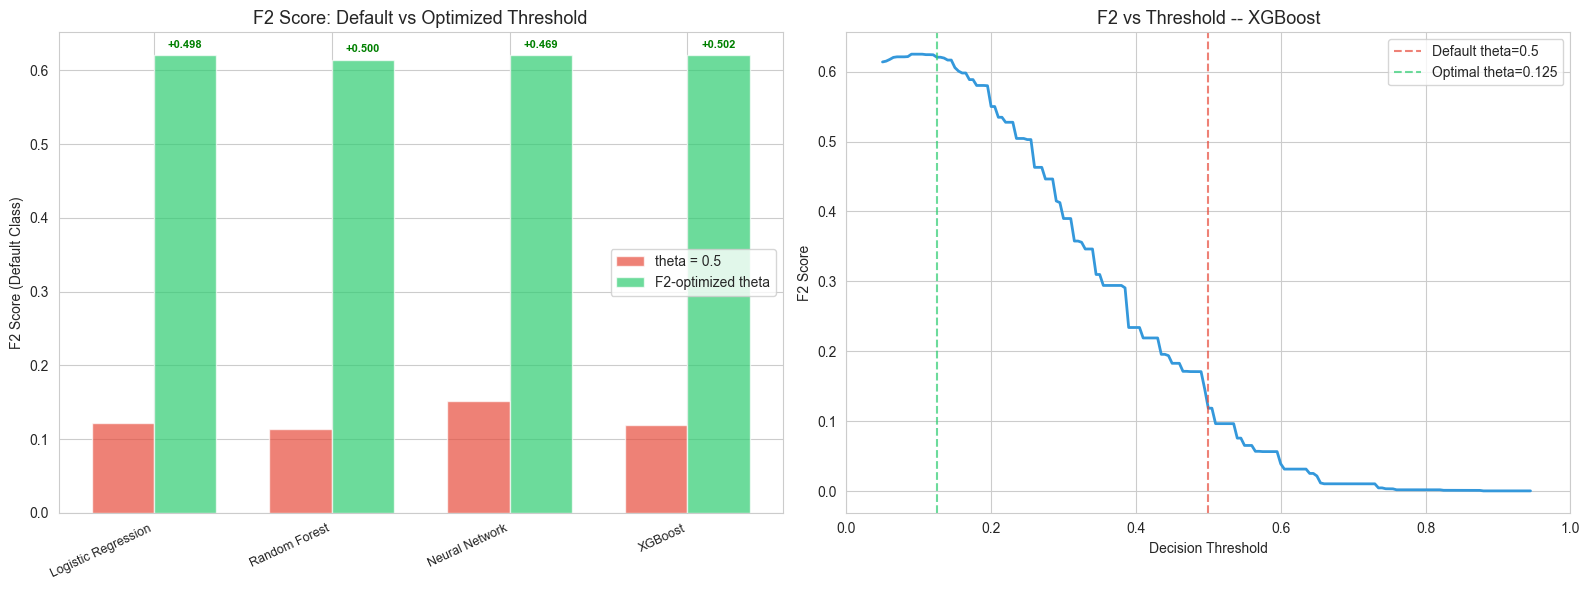

In [23]:
# Visualization 1: F2 improvement bar chart + threshold curve
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_names = list(model_registry.keys())
x = np.arange(len(model_names))
width = 0.35

axes[0].bar(x - width/2, df_default.loc[model_names, 'F2'], width,
            label='theta = 0.5', color=C_RED, alpha=0.7)
axes[0].bar(x + width/2, df_optimized.loc[model_names, 'F2'], width,
            label='F2-optimized theta', color=C_GREEN, alpha=0.7)
axes[0].set_ylabel('F2 Score (Default Class)')
axes[0].set_title('F2 Score: Default vs Optimized Threshold', fontsize=13)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=25, ha='right', fontsize=9)
axes[0].legend()
for i_bar, (f2_old, f2_new) in enumerate(zip(df_default.loc[model_names, 'F2'],
                                               df_optimized.loc[model_names, 'F2'])):
    axes[0].annotate(f'+{f2_new - f2_old:.3f}', (i_bar + width/2, f2_new + 0.01),
                     ha='center', fontsize=8, color='green', fontweight='bold')

best_name = df_optimized['F2'].idxmax()
best_test_prob = model_registry[best_name][0]
thresholds = np.arange(0.05, 0.95, 0.005)
f2_scores = [fbeta_score(y_test, (best_test_prob >= t).astype(int), beta=2) for t in thresholds]
axes[1].plot(thresholds, f2_scores, color=C_BLUE, linewidth=2)
axes[1].axvline(x=0.5, color=C_RED, linestyle='--', alpha=0.7, label='Default theta=0.5')
axes[1].axvline(x=optimal_thresholds[best_name], color=C_GREEN, linestyle='--', alpha=0.7,
                label=f'Optimal theta={optimal_thresholds[best_name]:.3f}')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('F2 Score')
axes[1].set_title(f'F2 vs Threshold -- {best_name}', fontsize=13)
axes[1].legend()
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

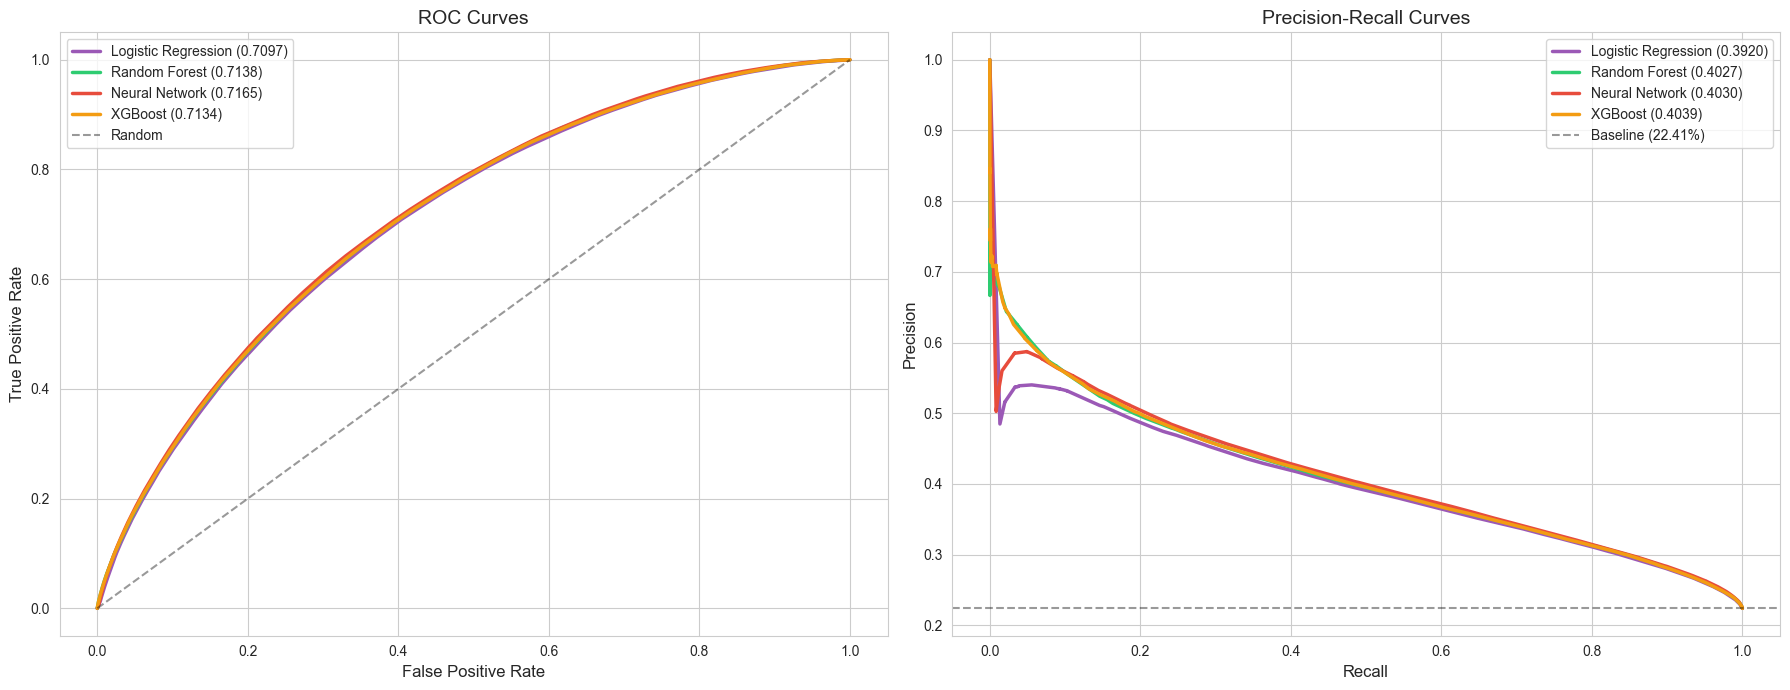

In [24]:
# Visualization 2: ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

colors = {'Logistic Regression': C_PURPLE, 'Random Forest': C_GREEN, 'Neural Network': C_RED, 'XGBoost': C_ORANGE}

for name, (test_prob, _) in model_registry.items():
    fpr, tpr, _ = roc_curve(y_test, test_prob)
    auc = roc_auc_score(y_test, test_prob)
    axes[0].plot(fpr, tpr, color=colors[name], linewidth=2.5, label=f'{name} ({auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curves', fontsize=14)
axes[0].legend(fontsize=10)

for name, (test_prob, _) in model_registry.items():
    prec, rec, _ = precision_recall_curve(y_test, test_prob)
    ap = average_precision_score(y_test, test_prob)
    axes[1].plot(rec, prec, color=colors[name], linewidth=2.5, label=f'{name} ({ap:.4f})')
baseline = y_test.mean()
axes[1].axhline(y=baseline, color='k', linestyle='--', alpha=0.4, label=f'Baseline ({baseline:.2%})')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curves', fontsize=14)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

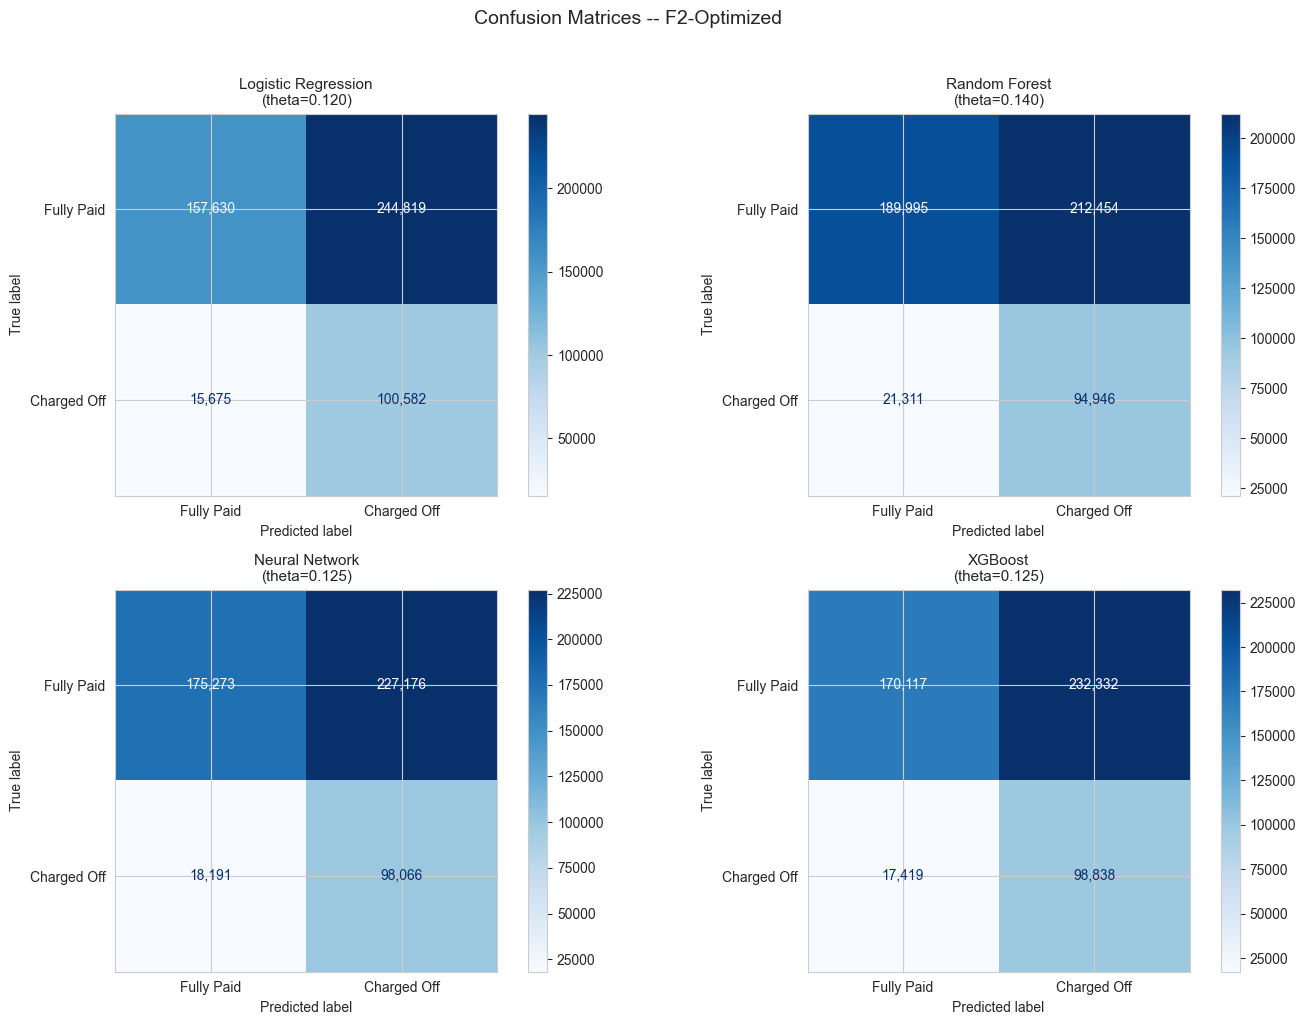

In [25]:
# Confusion matrices (4 models, 2x2 layout)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.flatten()

for ax, name in zip(axes_flat, model_registry.keys()):
    test_prob = model_registry[name][0]
    thresh = optimal_thresholds[name]
    pred_opt = (test_prob >= thresh).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred_opt,
        display_labels=['Fully Paid', 'Charged Off'],
        cmap='Blues', ax=ax, values_format=','
    )
    ax.set_title(f'{name}\n(theta={thresh:.3f})', fontsize=11)

plt.suptitle('Confusion Matrices -- F2-Optimized', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Calibration Curves (Reliability Diagrams)

Calibration curves show how well predicted probabilities match actual default rates. A perfectly calibrated model follows the diagonal. This is critical for lending -- well-calibrated probabilities directly translate to accurate risk pricing.

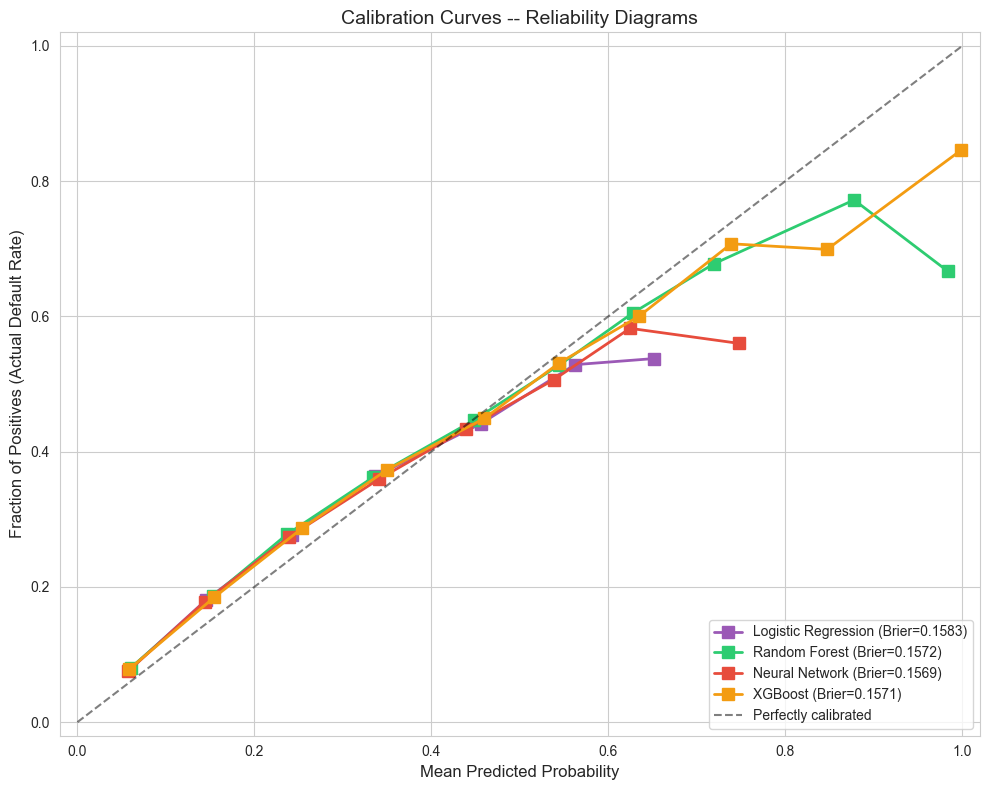

In [26]:
# Calibration curves for all 3 models
fig, ax = plt.subplots(figsize=(10, 8))
colors = {'Logistic Regression': C_PURPLE, 'Random Forest': C_GREEN, 'Neural Network': C_RED, 'XGBoost': C_ORANGE}

for name, (test_prob, _) in model_registry.items():
    fraction_pos, mean_pred = calibration_curve(y_test, test_prob, n_bins=10, strategy='uniform')
    brier = brier_score_loss(y_test, test_prob)
    ax.plot(mean_pred, fraction_pos, 's-', color=colors[name], linewidth=2,
            label=f'{name} (Brier={brier:.4f})', markersize=8)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfectly calibrated')
ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Fraction of Positives (Actual Default Rate)', fontsize=12)
ax.set_title('Calibration Curves -- Reliability Diagrams', fontsize=14)
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
plt.tight_layout()
plt.show()

### Predicted Probability Distributions by Actual Class

These histograms show how each model distributes predicted probabilities for actual defaults vs non-defaults. Better separation between the two distributions means the model more clearly distinguishes the two classes.

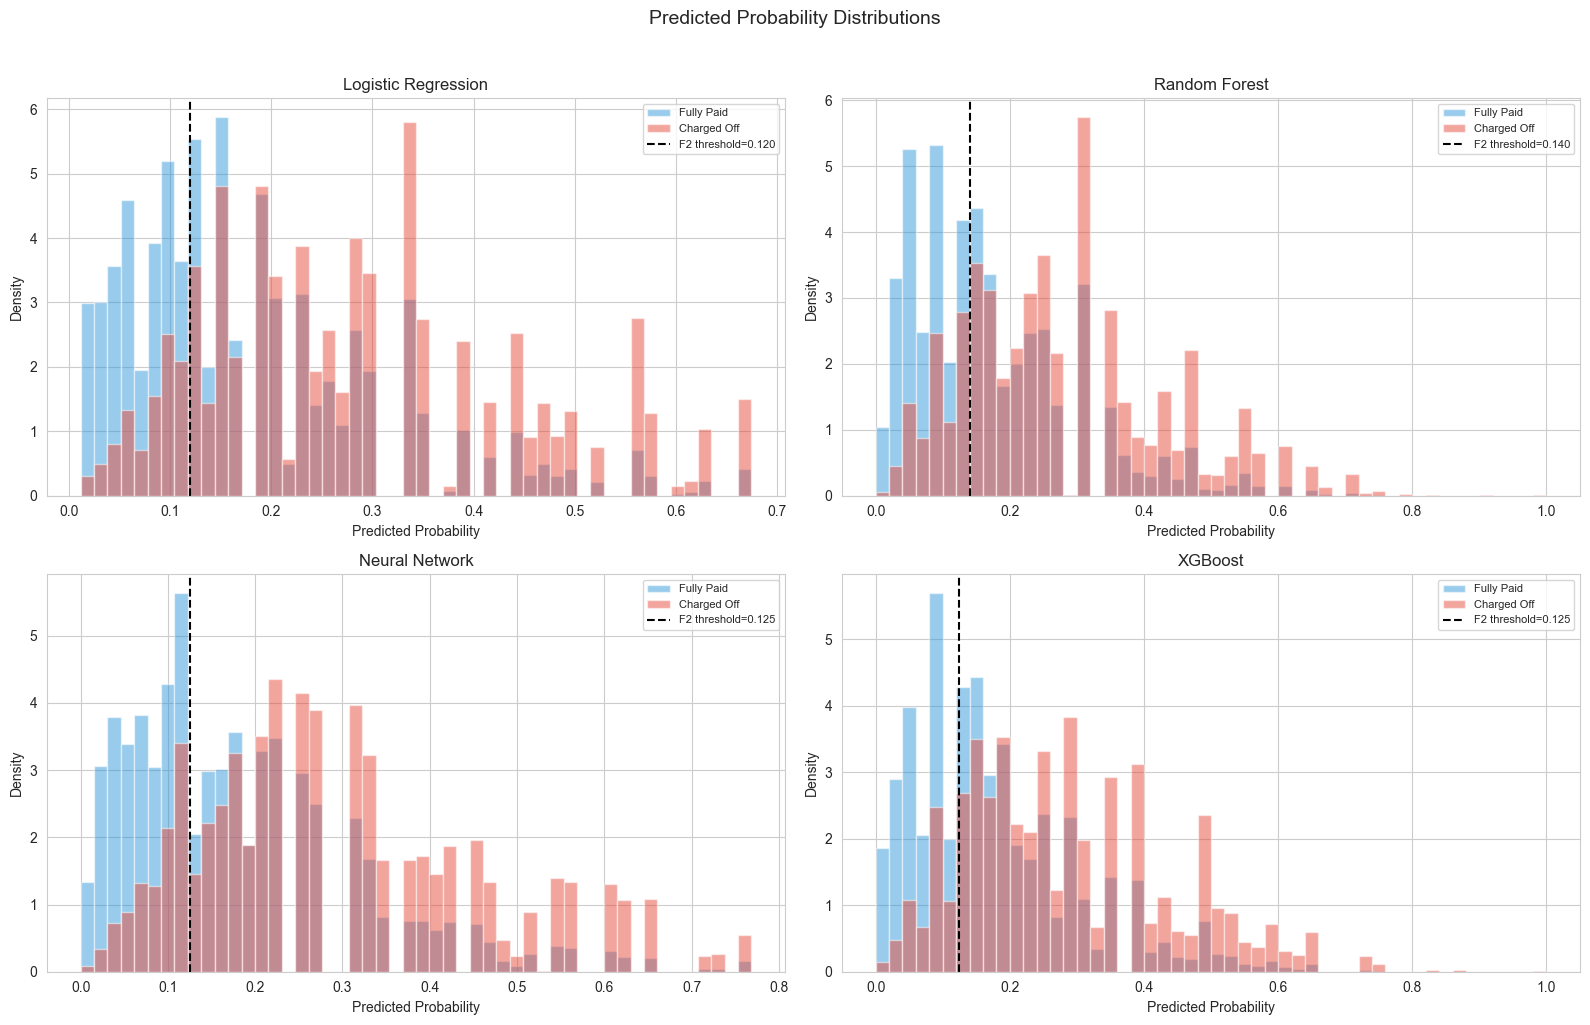

In [27]:
# Probability distributions (4 models, 2x2)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes_flat = axes.flatten()
model_names = list(model_registry.keys())

for ax, name in zip(axes_flat, model_names):
    test_prob = model_registry[name][0]
    ax.hist(test_prob[y_test == 0], bins=50, alpha=0.5, color=C_BLUE,
            label='Fully Paid', density=True, edgecolor='white')
    ax.hist(test_prob[y_test == 1], bins=50, alpha=0.5, color=C_RED,
            label='Charged Off', density=True, edgecolor='white')
    thresh = optimal_thresholds[name]
    ax.axvline(x=thresh, color='black', linestyle='--', linewidth=1.5,
               label=f'F2 threshold={thresh:.3f}')
    ax.set_xlabel('Predicted Probability'); ax.set_ylabel('Density')
    ax.set_title(f'{name}', fontsize=12); ax.legend(fontsize=8)

plt.suptitle('Predicted Probability Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Precision, Recall, and F2 vs Decision Threshold

These plots show how precision, recall, and F2 score change as we sweep the decision threshold from 0 to 1. The vertical dashed line marks the F2-optimal threshold chosen on the validation set.

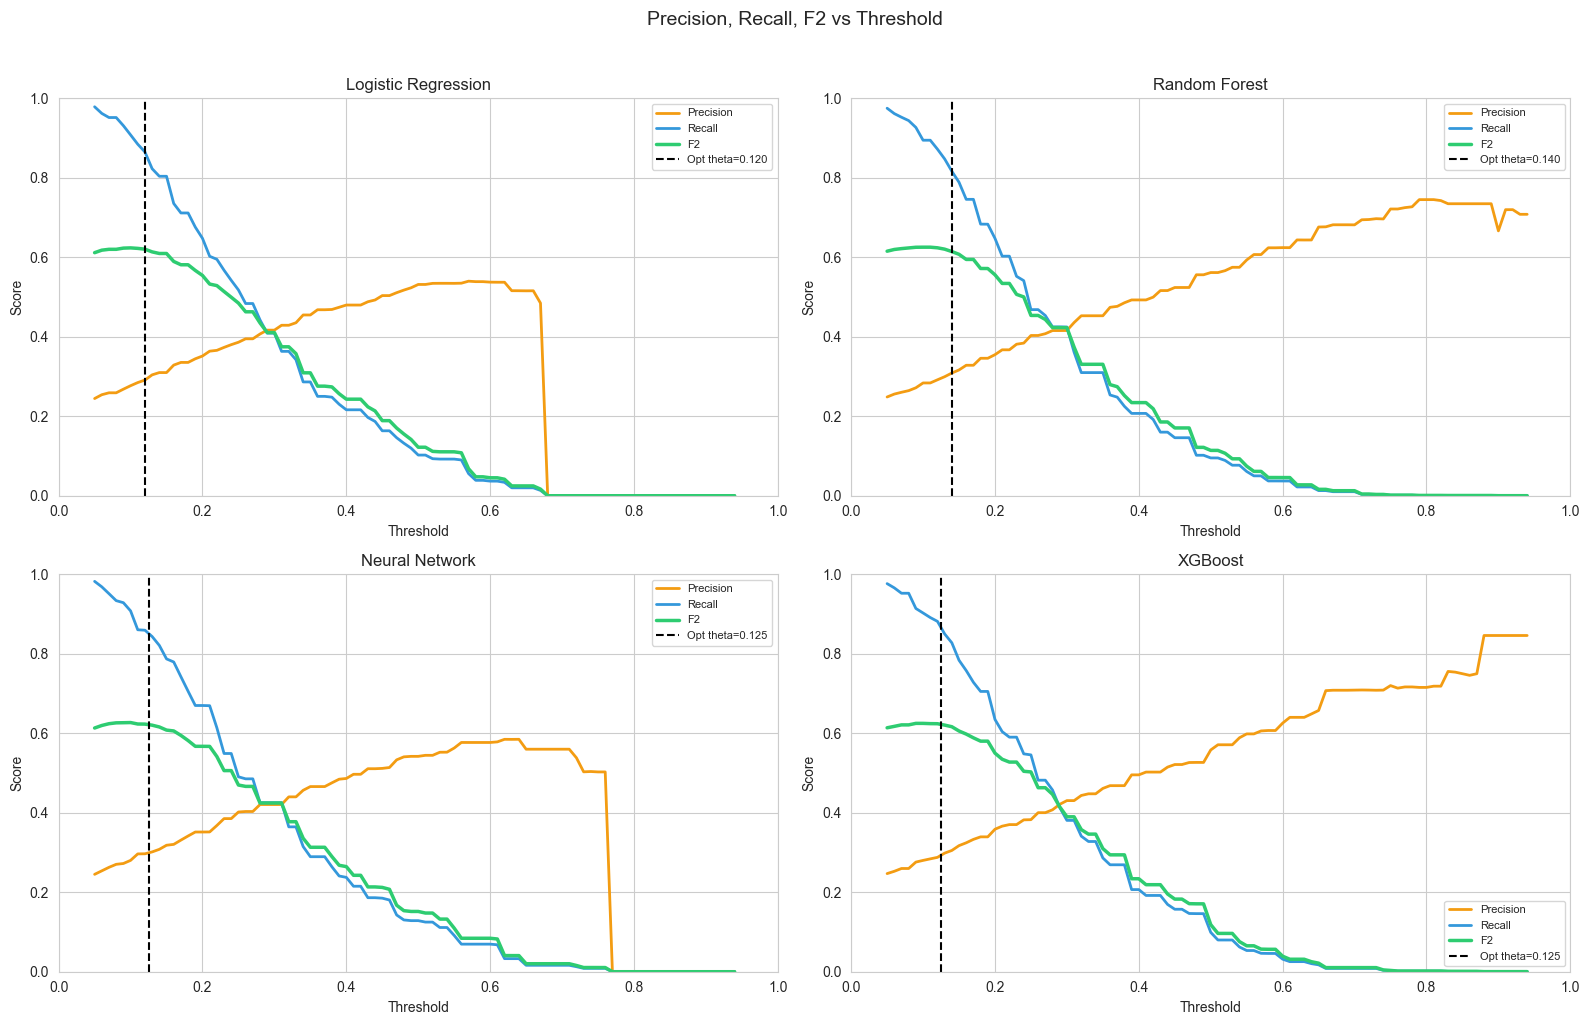

In [28]:
# Precision, Recall, F2 vs threshold (4 models, 2x2)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes_flat = axes.flatten()
model_names = list(model_registry.keys())
thresholds = np.arange(0.05, 0.95, 0.01)

for ax, name in zip(axes_flat, model_names):
    test_prob = model_registry[name][0]
    precisions = [precision_score(y_test, (test_prob >= t).astype(int), zero_division=0) for t in thresholds]
    recalls = [recall_score(y_test, (test_prob >= t).astype(int)) for t in thresholds]
    f2s = [fbeta_score(y_test, (test_prob >= t).astype(int), beta=2) for t in thresholds]

    ax.plot(thresholds, precisions, color=C_ORANGE, linewidth=2, label='Precision')
    ax.plot(thresholds, recalls, color=C_BLUE, linewidth=2, label='Recall')
    ax.plot(thresholds, f2s, color=C_GREEN, linewidth=2.5, label='F2')
    ax.axvline(x=optimal_thresholds[name], color='black', linestyle='--',
               linewidth=1.5, label=f'Opt theta={optimal_thresholds[name]:.3f}')
    ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
    ax.set_title(f'{name}', fontsize=12); ax.legend(fontsize=8)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.suptitle('Precision, Recall, F2 vs Threshold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Feature Importance Comparison Across Models

Comparing feature importances across models reveals which features are universally important (consensus drivers) versus model-specific. We use absolute coefficients for LR, Gini importance for RF, gain for XGBoost, and permutation importance for NN.

Computing permutation importance for Neural Network...


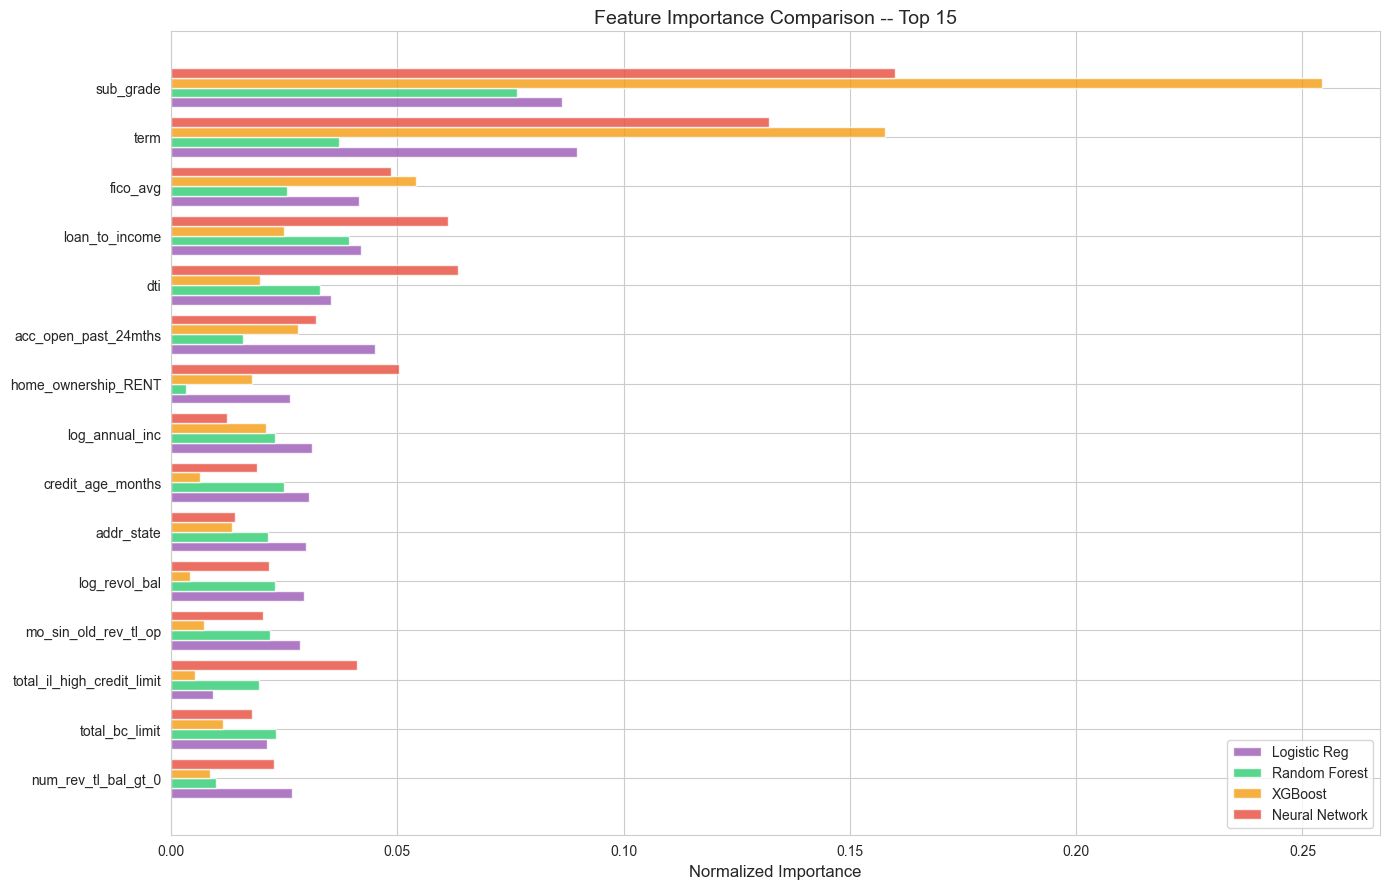


Top 5 consensus features:
  1. sub_grade: LR=0.0865 RF=0.0765 XGB=0.2544 NN=0.1600
  2. term: LR=0.0898 RF=0.0371 XGB=0.1577 NN=0.1321
  3. fico_avg: LR=0.0415 RF=0.0256 XGB=0.0541 NN=0.0485
  4. loan_to_income: LR=0.0419 RF=0.0393 XGB=0.0249 NN=0.0612
  5. dti: LR=0.0353 RF=0.0329 XGB=0.0197 NN=0.0635


In [29]:
# Feature importance comparison (4 models)
lr_imp = pd.Series(np.abs(lr_best.coef_[0]), index=feature_names)
lr_imp = lr_imp / lr_imp.sum()

rf_imp = pd.Series(rf_best.feature_importances_, index=feature_names)
rf_imp = rf_imp / rf_imp.sum()

xgb_imp = pd.Series(xgb_raw.feature_importances_, index=feature_names)
xgb_imp = xgb_imp / xgb_imp.sum()

print("Computing permutation importance for Neural Network...")
np.random.seed(42)
perm_idx = np.random.choice(len(X_test), size=5000, replace=False)
perm_result = permutation_importance(
    mlp_wrapper, X_test[perm_idx], y_test[perm_idx],
    n_repeats=5, random_state=42, scoring='average_precision', n_jobs=-1
)
nn_imp = pd.Series(perm_result.importances_mean, index=feature_names)
nn_imp = np.maximum(nn_imp, 0)
nn_imp = nn_imp / nn_imp.sum() if nn_imp.sum() > 0 else nn_imp

avg_imp = (lr_imp + rf_imp + xgb_imp + nn_imp) / 4
top15 = avg_imp.nlargest(15).index

fig, ax = plt.subplots(figsize=(14, 9))
y_pos = np.arange(len(top15))
w = 0.2

ax.barh(y_pos - 1.5*w, lr_imp[top15].values[::-1], w, color=C_PURPLE, label='Logistic Reg', alpha=0.8)
ax.barh(y_pos - 0.5*w, rf_imp[top15].values[::-1], w, color=C_GREEN, label='Random Forest', alpha=0.8)
ax.barh(y_pos + 0.5*w, xgb_imp[top15].values[::-1], w, color=C_ORANGE, label='XGBoost', alpha=0.8)
ax.barh(y_pos + 1.5*w, nn_imp[top15].values[::-1], w, color=C_RED, label='Neural Network', alpha=0.8)

ax.set_yticks(y_pos)
ax.set_yticklabels(top15[::-1], fontsize=10)
ax.set_xlabel('Normalized Importance', fontsize=12)
ax.set_title('Feature Importance Comparison -- Top 15', fontsize=14)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("\nTop 5 consensus features:")
for i, (feat, imp) in enumerate(avg_imp.nlargest(5).items(), 1):
    print(f"  {i}. {feat}: LR={lr_imp[feat]:.4f} RF={rf_imp[feat]:.4f} XGB={xgb_imp[feat]:.4f} NN={nn_imp[feat]:.4f}")

### Prediction Agreement / Disagreement Analysis

This analysis shows how often the four models agree on their predictions. High agreement suggests robust decision-making; disagreement reveals boundary cases where model diversity provides value.

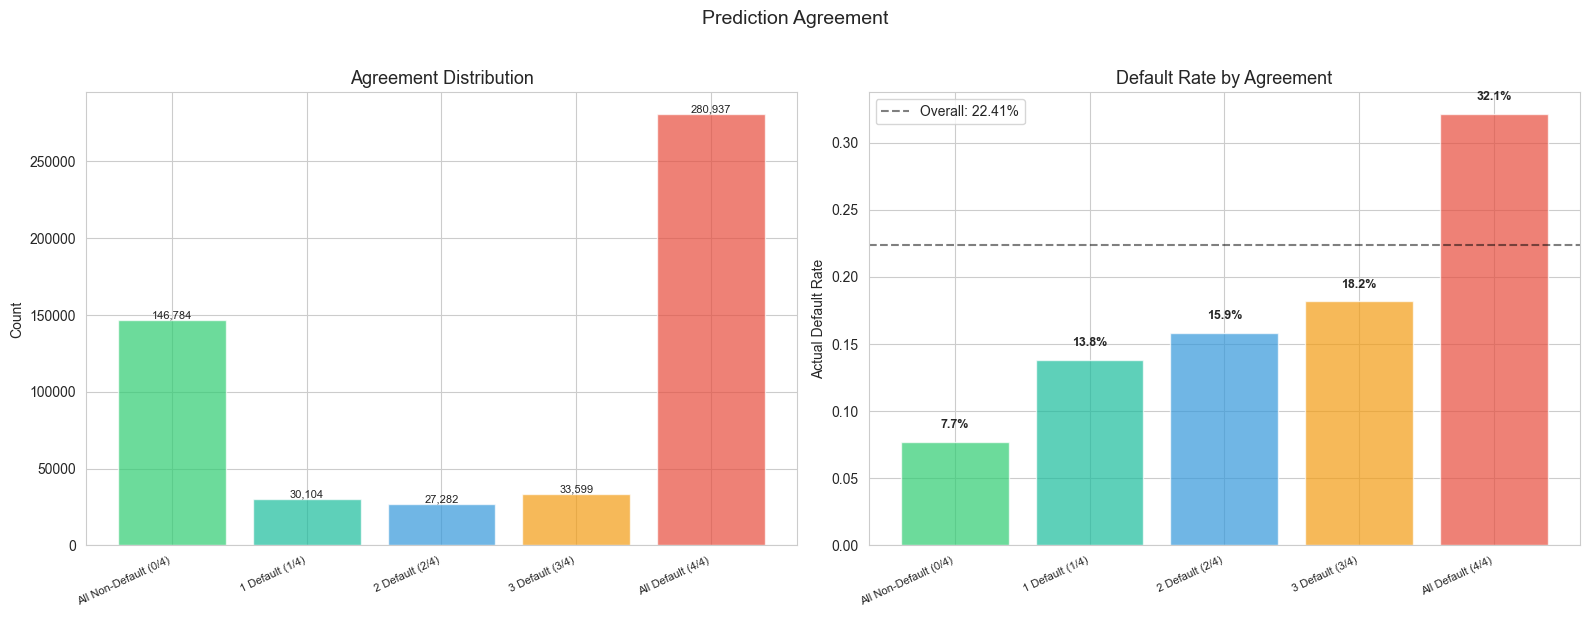


Full agreement: 427,721 / 518,706 (82.5%)
Majority vote F2: 0.6244


In [30]:
# Prediction agreement (4 models)
preds = {}
for name, (test_prob, _) in model_registry.items():
    preds[name] = (test_prob >= optimal_thresholds[name]).astype(int)

pred_matrix = np.column_stack([preds[n] for n in model_registry.keys()])
vote_sum = pred_matrix.sum(axis=1)

categories = {
    'All Non-Default (0/4)': (vote_sum == 0),
    '1 Default (1/4)': (vote_sum == 1),
    '2 Default (2/4)': (vote_sum == 2),
    '3 Default (3/4)': (vote_sum == 3),
    'All Default (4/4)': (vote_sum == 4),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
labels = list(categories.keys())
counts = [m.sum() for m in categories.values()]
rates = [y_test[m].mean() if m.sum() > 0 else 0 for m in categories.values()]
bar_colors = [C_GREEN, C_TEAL, C_BLUE, C_ORANGE, C_RED]

bars = axes[0].bar(range(len(labels)), counts, color=bar_colors, alpha=0.7)
axes[0].set_xticks(range(len(labels)))
axes[0].set_xticklabels(labels, rotation=25, ha='right', fontsize=8)
axes[0].set_ylabel('Count'); axes[0].set_title('Agreement Distribution', fontsize=13)
for bar, c in zip(bars, counts):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1000, f'{c:,}', ha='center', fontsize=8)

axes[1].bar(range(len(labels)), rates, color=bar_colors, alpha=0.7)
axes[1].set_xticks(range(len(labels)))
axes[1].set_xticklabels(labels, rotation=25, ha='right', fontsize=8)
axes[1].set_ylabel('Actual Default Rate'); axes[1].set_title('Default Rate by Agreement', fontsize=13)
axes[1].axhline(y=y_test.mean(), color='black', linestyle='--', alpha=0.5, label=f'Overall: {y_test.mean():.2%}')
axes[1].legend()
for i, r in enumerate(rates):
    axes[1].text(i, r+0.01, f'{r:.1%}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Prediction Agreement', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

full_agree = ((vote_sum == 0) | (vote_sum == 4)).sum()
print(f"\nFull agreement: {full_agree:,} / {len(y_test):,} ({full_agree/len(y_test):.1%})")
majority = (vote_sum >= 2).astype(int)
print(f"Majority vote F2: {fbeta_score(y_test, majority, beta=2):.4f}")

## 8. Application-Time vs Investor Model Comparison

Two prediction moments:
- **Application-time**: Before LendingClub assigns a grade. All features except `sub_grade`.
- **Investor**: After LC grades the loan. All features including `sub_grade`.

If the delta is small, `sub_grade` is redundant.

In [31]:
# Train app-time XGBoost (no sub_grade)
print(f"Training app-time XGBoost ({len(app_features)} features, no sub_grade)...")

xgb_app = XGBClassifier(**xgb_search.best_params_,
                         objective='binary:logistic', eval_metric='aucpr',
                         random_state=42, n_jobs=-1, verbosity=0)
t0 = time.time()
xgb_app.fit(X_train_app, y_train)
t_app = time.time() - t0
print(f"  Training time: {t_app:.1f}s")

# Calibrate
xgb_app_cal = CalibratedClassifierCV(FrozenEstimator(xgb_app), method='isotonic')
xgb_app_cal.fit(X_cal[:, app_idx], y_cal)

app_test_prob = xgb_app_cal.predict_proba(X_test_app)[:, 1]
app_thresh_prob = xgb_app_cal.predict_proba(X_thresh[:, app_idx])[:, 1]
app_f2_thresh, _ = find_optimal_threshold(y_thresh, app_thresh_prob, beta=2)
app_pred = (app_test_prob >= app_f2_thresh).astype(int)

# Investor model
inv_test_prob = model_registry['XGBoost'][0]
inv_thresh = optimal_thresholds['XGBoost']
inv_pred = (inv_test_prob >= inv_thresh).astype(int)

print(f"\n{'='*70}")
print("APPLICATION-TIME vs INVESTOR COMPARISON")
print(f"{'='*70}")
comp = pd.DataFrame({
    'App-Time': {
        'Features': len(app_features),
        'PR-AUC': average_precision_score(y_test, app_test_prob),
        'AUC-ROC': roc_auc_score(y_test, app_test_prob),
        'F2': fbeta_score(y_test, app_pred, beta=2),
        'Recall': recall_score(y_test, app_pred),
        'Brier': brier_score_loss(y_test, app_test_prob),
        'Threshold': app_f2_thresh,
    },
    'Investor (w/ sub_grade)': {
        'Features': len(feature_names),
        'PR-AUC': average_precision_score(y_test, inv_test_prob),
        'AUC-ROC': roc_auc_score(y_test, inv_test_prob),
        'F2': fbeta_score(y_test, inv_pred, beta=2),
        'Recall': recall_score(y_test, inv_pred),
        'Brier': brier_score_loss(y_test, inv_test_prob),
        'Threshold': inv_thresh,
    },
})
comp['Delta'] = comp['Investor (w/ sub_grade)'] - comp['App-Time']
print(comp.round(4).to_string())

pr_delta = comp.loc['PR-AUC', 'Delta']
print(f"\nPR-AUC delta: {pr_delta:+.4f}")
if abs(pr_delta) < 0.01:
    print("  -> sub_grade adds minimal value; app-time model is sufficient")
else:
    print(f"  -> sub_grade adds meaningful signal")

Training app-time XGBoost (72 features, no sub_grade)...
  Training time: 26.0s

APPLICATION-TIME vs INVESTOR COMPARISON
           App-Time  Investor (w/ sub_grade)   Delta
Features    72.0000                  73.0000  1.0000
PR-AUC       0.3916                   0.4039  0.0123
AUC-ROC      0.6995                   0.7134  0.0139
F2           0.6099                   0.6207  0.0108
Recall       0.8373                   0.8502  0.0128
Brier        0.1597                   0.1571 -0.0027
Threshold    0.1250                   0.1250  0.0000

PR-AUC delta: +0.0123
  -> sub_grade adds meaningful signal


## 9. Right-Censoring Sensitivity

60-month loans issued in 2017+ cannot have matured by 2018Q4. We evaluate on the "safe" subset excluding these.

In [32]:
# Right-censoring analysis
is_60month = (term_test == 60)
is_2017plus = (test_dates >= np.datetime64('2017-01-01'))
right_censored = is_60month & is_2017plus
safe_mask = ~right_censored

print(f"Test set right-censoring:")
print(f"  Total:          {len(y_test):,}")
print(f"  60-month 2017+: {right_censored.sum():,} ({right_censored.mean():.1%})")
print(f"  Safe:           {safe_mask.sum():,} ({safe_mask.mean():.1%})")
print(f"  Default (all):  {y_test.mean():.2%}")
print(f"  Default (safe): {y_test[safe_mask].mean():.2%}")

print(f"\n{'='*80}")
print("RIGHT-CENSORING SENSITIVITY: Full vs Safe Test Set")
print(f"{'='*80}")
print(f"{'Model':<24} {'PR-AUC full':>12} {'PR-AUC safe':>12} {'F2 full':>8} {'F2 safe':>8}")
print("-" * 68)

for name, (test_prob, _) in model_registry.items():
    thresh = optimal_thresholds[name]
    pred_f = (test_prob >= thresh).astype(int)
    pred_s = (test_prob[safe_mask] >= thresh).astype(int)
    pr_f = average_precision_score(y_test, test_prob)
    pr_s = average_precision_score(y_test[safe_mask], test_prob[safe_mask])
    f2_f = fbeta_score(y_test, pred_f, beta=2)
    f2_s = fbeta_score(y_test[safe_mask], pred_s, beta=2)
    print(f"{name:<24} {pr_f:>12.4f} {pr_s:>12.4f} {f2_f:>8.4f} {f2_s:>8.4f}")

Test set right-censoring:
  Total:          518,706
  60-month 2017+: 55,805 (10.8%)
  Safe:           462,901 (89.2%)
  Default (all):  22.41%
  Default (safe): 21.48%

RIGHT-CENSORING SENSITIVITY: Full vs Safe Test Set
Model                     PR-AUC full  PR-AUC safe  F2 full  F2 safe
--------------------------------------------------------------------
Logistic Regression            0.3920       0.3880   0.6205   0.6086
Random Forest                  0.4027       0.3983   0.6146   0.6005
Neural Network                 0.4030       0.4006   0.6205   0.6078
XGBoost                        0.4039       0.3992   0.6207   0.6082


## 10. Final Model Selection

### Selection Criteria

We evaluate models along four dimensions:
1. **Performance**: PR-AUC (primary, threshold-independent), F2 (recall-weighted), F1, MCC
2. **Calibration**: Brier score -- how well probabilities reflect true default rates
3. **Interpretability**: Can we explain why the model flags specific loans?
4. **Robustness**: Stability across temporal drift + training speed

In [33]:
# Final comparison (4 models)
results_final = df_optimized.copy()
interp = {
    'Logistic Regression': 'High (coefficients)',
    'Random Forest': 'High (Gini importances)',
    'Neural Network': 'Low (black box)',
    'XGBoost': 'Medium (SHAP)',
}

results_final['Train Time'] = [f'{train_times[n]:.0f}s' for n in results_final.index]
results_final['Interpretability'] = [interp[n] for n in results_final.index]

print("=" * 110)
print("FINAL MODEL COMPARISON (Calibrated, F2-Optimized, Test Set)")
print("=" * 110)
print(results_final.round(4).to_string())
print()

best_f2 = results_final['F2'].idxmax()
best_pr = results_final['PR-AUC'].idxmax()
best_brier = results_final['Brier'].idxmin()
print(f"Best by F2:     {best_f2} ({results_final.loc[best_f2, 'F2']:.4f})")
print(f"Best by PR-AUC: {best_pr} ({results_final.loc[best_pr, 'PR-AUC']:.4f})")
print(f"Best by Brier:  {best_brier} ({results_final.loc[best_brier, 'Brier']:.4f})")

FINAL MODEL COMPARISON (Calibrated, F2-Optimized, Test Set)
                     Threshold  Accuracy  Precision  Recall      F1      F2  AUC-ROC  PR-AUC     MCC   Brier Train Time         Interpretability
Model                                                                                                                                           
Logistic Regression      0.120    0.4978     0.2912  0.8652  0.4357  0.6205   0.7097  0.3920  0.2271  0.1583        47s      High (coefficients)
Random Forest            0.140    0.5493     0.3089  0.8167  0.4482  0.6146   0.7138  0.4027  0.2451  0.1572       152s  High (Gini importances)
Neural Network           0.125    0.5270     0.3015  0.8435  0.4442  0.6205   0.7165  0.4030  0.2406  0.1569       100s          Low (black box)
XGBoost                  0.125    0.5185     0.2985  0.8502  0.4418  0.6207   0.7134  0.4039  0.2368  0.1571        29s            Medium (SHAP)

Best by F2:     XGBoost (0.6207)
Best by PR-AUC: XGBoost (0.4039)
Bes

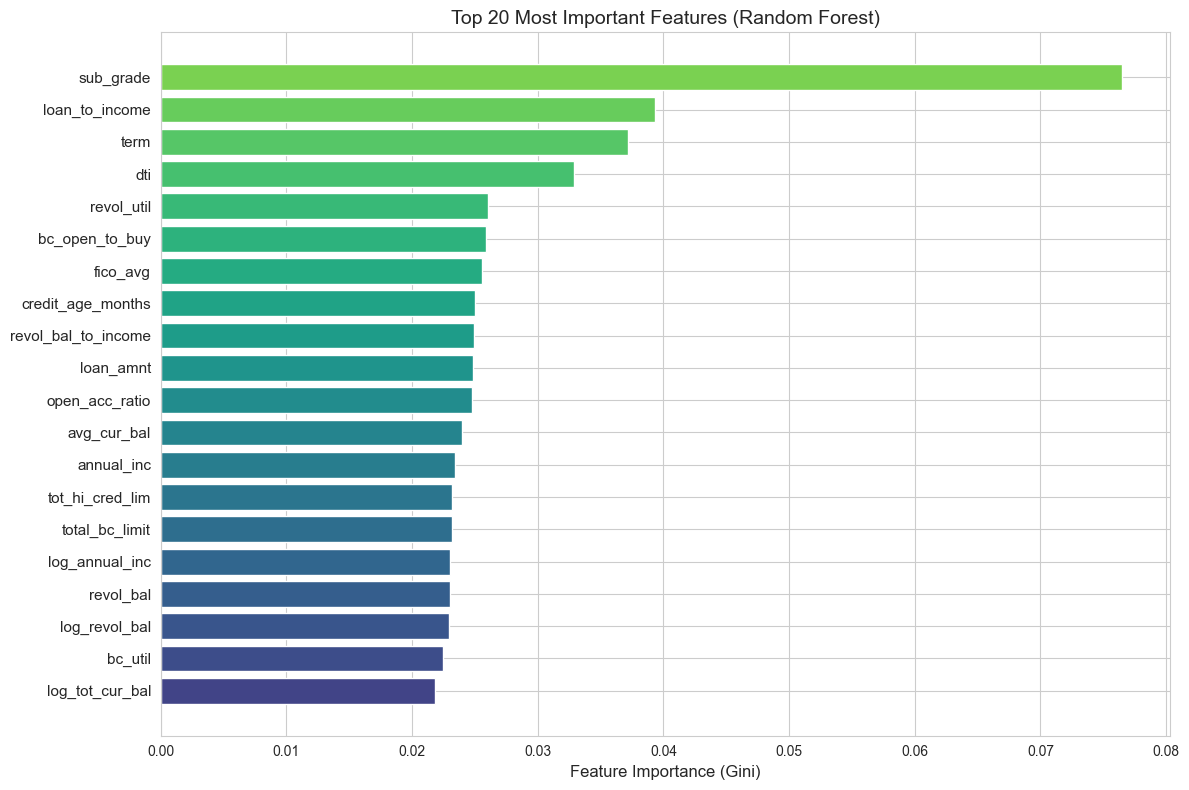


Top 10 features driving default prediction:
  1. sub_grade: 0.0765
  2. loan_to_income: 0.0393
  3. term: 0.0371
  4. dti: 0.0329
  5. revol_util: 0.0260
  6. bc_open_to_buy: 0.0259
  7. fico_avg: 0.0256
  8. credit_age_months: 0.0250
  9. revol_bal_to_income: 0.0249
  10. loan_amnt: 0.0248


In [34]:
# Final feature importance — top 20 (from RF, most interpretable)
feat_imp = pd.Series(rf_best.feature_importances_, index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
top_20 = feat_imp.head(20)
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top_20)))
ax.barh(range(len(top_20)), top_20.values[::-1], color=colors, edgecolor='white')
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20.index[::-1], fontsize=11)
ax.set_xlabel('Feature Importance (Gini)', fontsize=12)
ax.set_title('Top 20 Most Important Features (Random Forest)', fontsize=14)
plt.tight_layout()
plt.show()

print("\nTop 10 features driving default prediction:")
for i, (name, imp) in enumerate(feat_imp.head(10).items(), 1):
    print(f"  {i}. {name}: {imp:.4f}")

## 11. SHAP Analysis -- Model Interpretability

SHAP (SHapley Additive exPlanations) provides model-agnostic feature attributions. We compute SHAP values for both **XGBoost** and **Random Forest** using their native `TreeExplainer` backends.

SHAP plots show:
- **Global importance**: which features matter most across all predictions
- **Beeswarm**: how each feature's value (high/low) pushes predictions toward default or non-default
- **Dependence**: interaction between the top feature and the target

In [35]:
# SHAP via native TreeExplainer
SHAP_SAMPLE = 500
np.random.seed(42)
shap_idx = np.random.choice(len(X_test), size=SHAP_SAMPLE, replace=False)
X_shap = pd.DataFrame(X_test[shap_idx], columns=feature_names)

# XGBoost SHAP (use raw model, not calibrated wrapper)
t0 = time.time()
explainer_xgb = shap.TreeExplainer(xgb_raw)
shap_values_xgb = explainer_xgb.shap_values(X_shap)
print(f"XGBoost SHAP ({SHAP_SAMPLE} samples): {time.time() - t0:.1f}s")

# Random Forest SHAP — approximate=True for speed
t0 = time.time()
explainer_rf = shap.TreeExplainer(rf_best)
shap_values_rf_raw = explainer_rf.shap_values(X_shap, approximate=True)
# Handle different return shapes: list of [class0, class1] or 3D array (samples, features, classes)
if isinstance(shap_values_rf_raw, list):
    shap_values_rf = shap_values_rf_raw[1]
elif shap_values_rf_raw.ndim == 3:
    shap_values_rf = shap_values_rf_raw[:, :, 1]
else:
    shap_values_rf = shap_values_rf_raw
print(f"Random Forest SHAP ({SHAP_SAMPLE} samples, approximate): {time.time() - t0:.1f}s")

shap_vals_default = shap_values_xgb

XGBoost SHAP (500 samples): 0.2s
Random Forest SHAP (500 samples, approximate): 1.5s


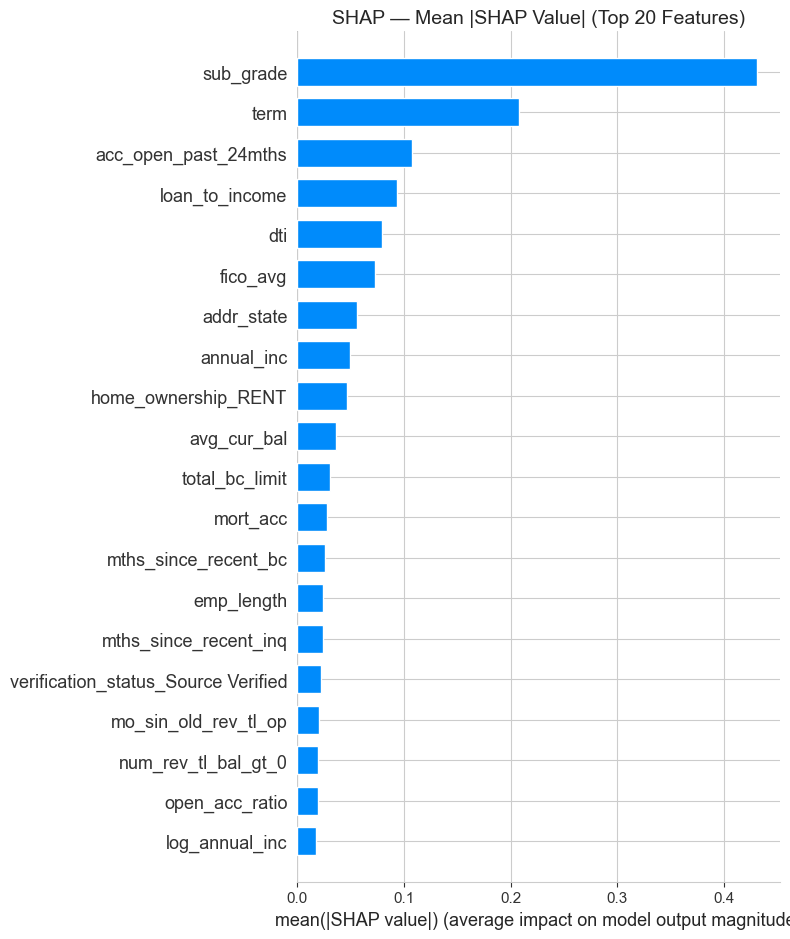

In [36]:
# SHAP summary bar plot — global feature importance
fig, ax = plt.subplots(figsize=(10, 10))
shap.summary_plot(shap_vals_default, X_shap, plot_type='bar', max_display=20, show=False)
plt.title('SHAP — Mean |SHAP Value| (Top 20 Features)', fontsize=14)
plt.tight_layout()
plt.show()

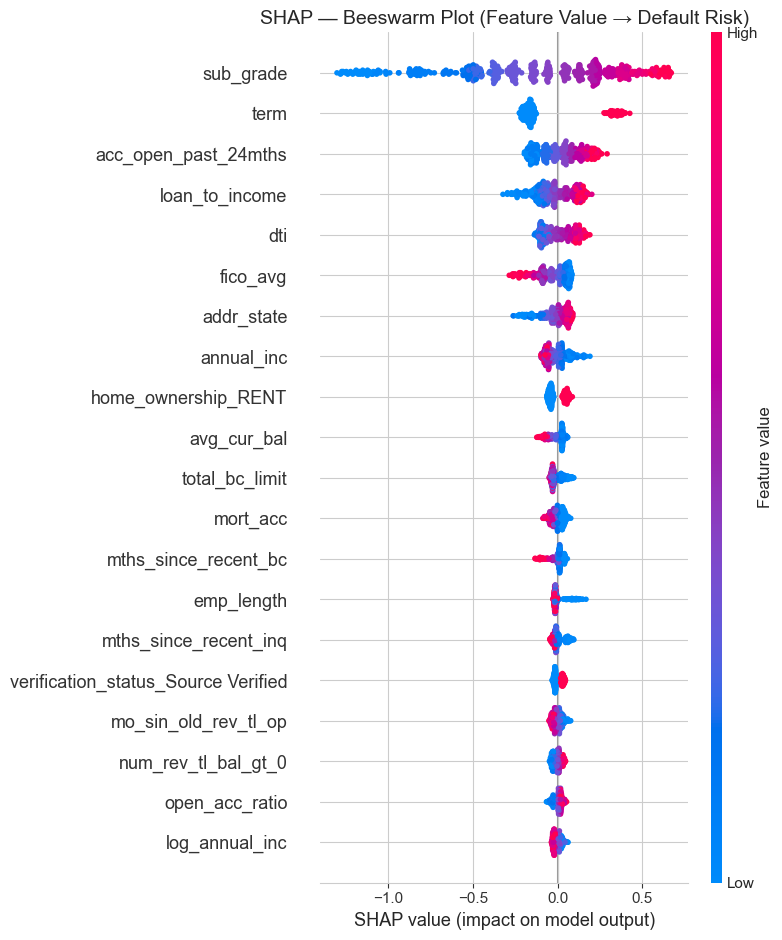

In [37]:
# SHAP beeswarm plot — feature value impact direction
fig, ax = plt.subplots(figsize=(10, 10))
shap.summary_plot(shap_vals_default, X_shap, max_display=20, show=False)
plt.title('SHAP — Beeswarm Plot (Feature Value → Default Risk)', fontsize=14)
plt.tight_layout()
plt.show()

Top SHAP feature: sub_grade


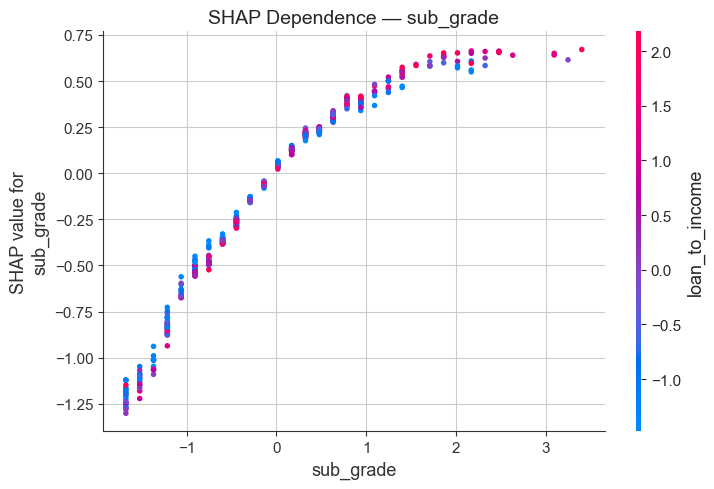

In [38]:
# SHAP dependence plot — top feature interaction
top_feature = pd.DataFrame(np.abs(shap_vals_default), columns=feature_names).mean().idxmax()
print(f"Top SHAP feature: {top_feature}")


shap.dependence_plot(top_feature, shap_vals_default, X_shap, show=False)
plt.title(f'SHAP Dependence — {top_feature}', fontsize=14)
plt.tight_layout()
plt.show()

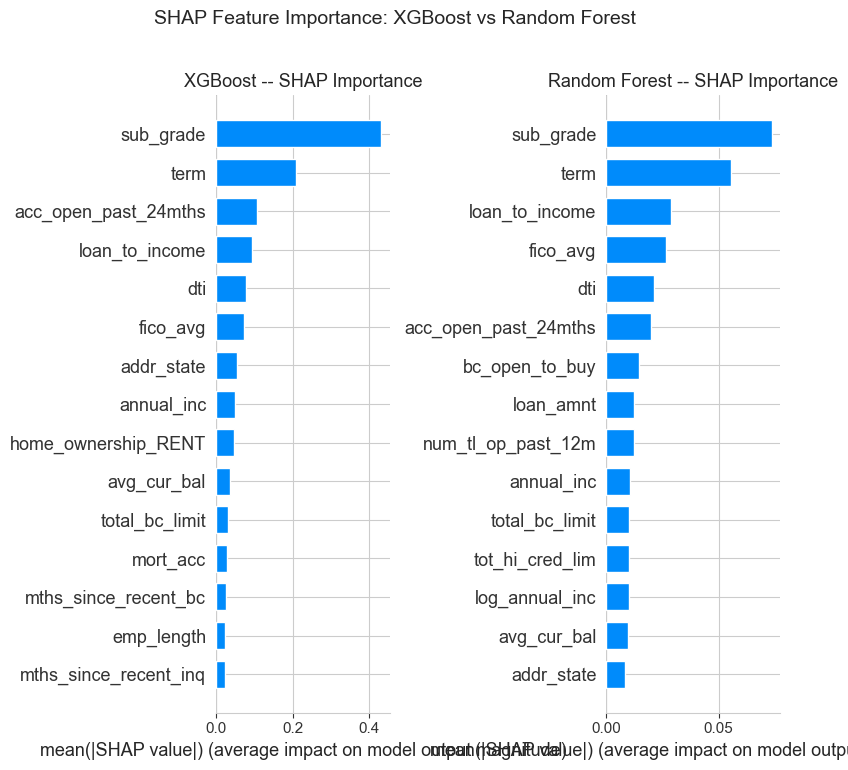

Spearman rank correlation (XGBoost vs RF SHAP importance): 0.8719
  1.0 = perfect agreement on feature ranking, 0.0 = no correlation


In [39]:
# Side-by-side SHAP comparison: XGBoost vs Random Forest
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

plt.sca(axes[0])
shap.summary_plot(shap_values_xgb, X_shap, plot_type='bar', max_display=15, show=False)
axes[0].set_title('XGBoost -- SHAP Importance', fontsize=13)

plt.sca(axes[1])
shap.summary_plot(shap_values_rf, X_shap, plot_type='bar', max_display=15, show=False)
axes[1].set_title('Random Forest -- SHAP Importance', fontsize=13)

plt.suptitle('SHAP Feature Importance: XGBoost vs Random Forest', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Rank correlation between XGBoost and RF SHAP importances
xgb_shap_imp = pd.Series(np.abs(shap_values_xgb).mean(axis=0), index=feature_names)
rf_shap_imp = pd.Series(np.abs(shap_values_rf).mean(axis=0), index=feature_names)
rank_corr = xgb_shap_imp.rank().corr(rf_shap_imp.rank(), method='spearman')
print(f"Spearman rank correlation (XGBoost vs RF SHAP importance): {rank_corr:.4f}")
print("  1.0 = perfect agreement on feature ranking, 0.0 = no correlation")

## 12. Conclusion

### Key Findings

1. **Leak-free preprocessing is critical.** StandardScaler, target encoding, NZV, and correlation filtering now fit on training data only.
2. **Isotonic calibration benefits ALL models.** Class weights distort probabilities across RF, LR, NN, and XGBoost.
3. **TimeSeriesSplit respects deployment reality.** Shuffled CV leaks future data into training folds.
4. **F2-optimized thresholds catch more defaults.** Missing a default is far costlier than rejecting a good loan.
5. **Application-time vs investor** clarifies what information is available at prediction time.
6. **Right-censoring matters** for temporal test sets with immature 60-month loans.


In [40]:
# --- Export models for Shiny web app ---
import pickle, json, os, shutil

app_model_dir = os.path.join('app', 'models')
os.makedirs(app_model_dir, exist_ok=True)

# 1. Save calibrated sklearn models (LR, RF, XGBoost -- skip NN)
for name, model_obj in [('lr_cal', lr_cal), ('rf_cal', rf_cal), ('xgb_cal', xgb_cal)]:
    path = os.path.join(app_model_dir, f'{name}.pkl')
    with open(path, 'wb') as f:
        pickle.dump(model_obj, f)
    print(f'Saved {path}')

# 2. Save optimal thresholds (F2-optimized)
thresholds_export = {k: float(v) for k, v in optimal_thresholds.items()
                     if k != 'Neural Network'}
with open(os.path.join(app_model_dir, 'thresholds.json'), 'w') as f:
    json.dump(thresholds_export, f, indent=2)
print(f'Saved thresholds: {thresholds_export}')

# 3. Copy preprocessing artifacts
shutil.copy2('data/preprocessing_artifacts.pkl',
             os.path.join(app_model_dir, 'preprocessing.pkl'))
print('Saved preprocessing.pkl')

# 4. Save median feature values (for default inputs in web app)
df_eng = pd.read_parquet('data/engineered.parquet')
medians = {}
for col in feature_names:
    if col == 'addr_state':
        medians[col] = 'CA'
    elif col in df_eng.columns:
        medians[col] = round(float(df_eng[col].astype(float).median()), 4)
    else:
        medians[col] = 0
with open(os.path.join(app_model_dir, 'medians.json'), 'w') as f:
    json.dump(medians, f, indent=2)
print(f'Saved medians for {len(medians)} features')

print('\nAll artifacts exported to app/models/')

Saved app/models/lr_cal.pkl
Saved app/models/rf_cal.pkl
Saved app/models/xgb_cal.pkl
Saved thresholds: {'Logistic Regression': 0.11999999999999997, 'Random Forest': 0.13999999999999996, 'XGBoost': 0.12499999999999997}
Saved preprocessing.pkl
Saved medians for 73 features

All artifacts exported to app/models/
